<img src="https://www.mmu.edu.my/fci/wp-content/uploads/2021/01/FCI_wNEW_MMU_LOGO.png" style="height: 80px;" align=left>

# CDS6314 - Data Mining Project (30%)

## **Group 26**
### **Tutorial Section**: TT3L
___________________________

#### **Members**:

|   | Student ID   | Student Name                              | Task Distribution                    |
|--:|:-------------|:-----------------------------------------:|:------------------------------------:|
| 1 | 1221305230 | Amany Sharaf El Deen Sami Al Horani | Data Collection, Initial Setup and Data Cleaning |
| 2 | 1191201544 | Irdinie Alieya Binti Ahmad Rizal | Exploratory Data Analysis |
| 3 | 1221305054 | Chin Jia Wen | Data Transformation, Model Selection and Training |
| 4 | 1221305394 | Looi Kai Jun | Hyperparameter Tuning and Model Evaluation |

   ___________________________

## **Domain**: Financial/Banking

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
<strong>Topic Chosen</strong>: Bank Marketing
</p>
<p style='text-align: justify;'>
<strong>Title</strong>: Optimizing Bank Telemarketing Campaigns through Data Mining: Predictive Modeling and Customer Segmentation
</p>
<p style='text-align: justify;'>
<strong>Dataset Description</strong>: The Bank Marketing dataset we selected contains information related to direct marketing campaigns (phone calls) of a Portuguese banking institution. The dataset was obtained from <a href='https://www.kaggle.com/datasets/berkayalan/bank-marketing-data-set'>Kaggle</a>  
</p>  
</div>

_____________________________

## **Data Collection and Initial Setup**
<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
The first step in the process is to collect the data and set up the environment.
</p>
</div>

### **Importing Necessary Libraries**

In [1]:
# Importing all necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Now we need to read the dataset and verify that it has been loaded correctly and then display the summary statistics of the dataset to get an overview.
</p>
</div>

### **Loading the Dataset**

In [2]:
# Reading the dataset into a pandas DataFrame

# Display all columns
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/bank_marketing_dataset.csv')

In [3]:
# Displaying the first few rows of the dataset to verify that it has been loaded correctly
print('First Few Rows of The Dataset:')
display(df.head())
df.shape[0]

First Few Rows of The Dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


41188

In [4]:
# Check dimensionality
print("Number of Rows:", df.shape[0])
print("Number of Features/Columns:", df.shape[1])

Number of Rows: 41188
Number of Features/Columns: 21


In [5]:
# Checking the data types of all our columns
df.dtypes 

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
subscribed         object
dtype: object

In [6]:
# Displaying summary statistics of the dataset to get an overview
print("Summary Statistics of the Dataset:")
df.describe()

Summary Statistics of the Dataset:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## **Data Preprocessing Part 1 - Data Cleaning**
<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
This section involves handling missing values, duplicates and outliers once the data has been loaded.
</p>
</div>

In [7]:
# Checking for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
subscribed        0
dtype: int64


<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Since there are no missing values in our data, we do not need to perform imputation. Therefore, we skip the imputation step and focus on the next step which is to check for any duplicate records.
</p>
</div>

In [8]:
# Checking for duplicate records in the dataset
print("Checking for Duplicate Records...")
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
print(f"Number of Duplicated Records: {num_duplicates}")

Checking for Duplicate Records...
Number of Duplicated Records: 12


In [9]:
# Since there are duplicate records, let's view them.
if num_duplicates > 0:
    print("Duplicate Records:")
    display(df[duplicates])

Duplicate Records:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,33,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,127,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,123,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [10]:
# Now to remove the duplicate records from the dataset
print(f"Number of Rows Before Removing Duplicates: {df.shape[0]}")
df = df.drop_duplicates()
print(f"Number of Rows After Removing Duplicates: {df.shape[0]}")

# Checking again to make sure the duplicate records were removed successfully
print("Checking for Duplicate Records...")
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
print(f"Number of Duplicated Records: {num_duplicates}")

Number of Rows Before Removing Duplicates: 41188
Number of Rows After Removing Duplicates: 41176
Checking for Duplicate Records...
Number of Duplicated Records: 0


### **Outlier Detection and Handling**

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
First, we need to create two functions. One for the detection and handling of the numerical outliers, and the other for the visualization of the box plots to make sure the outliers were handled appropriately and correctly.
</p>
<p style='text-align: justify;'>
The visualization of outlier boxplots was written as a function. This was done to reuse the code without rewriting it every time we need to visualize the outliers (before and after).
</p>
</div>

In [11]:
# Function to detect and handle numercial outliers using the IQR method
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

# Function to visualize box plots
def plot_box_plots(df, cols, title_suffix):
    num_cols = 5
    num_rows = (len(cols) + num_cols - 1) // num_cols

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(21, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f"Box Plot for {col} {title_suffix}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Next, we need to visualize the outliers using box plots before handling them so that we can compare with the box plots after the outliers have been handled.
</p>
</div>

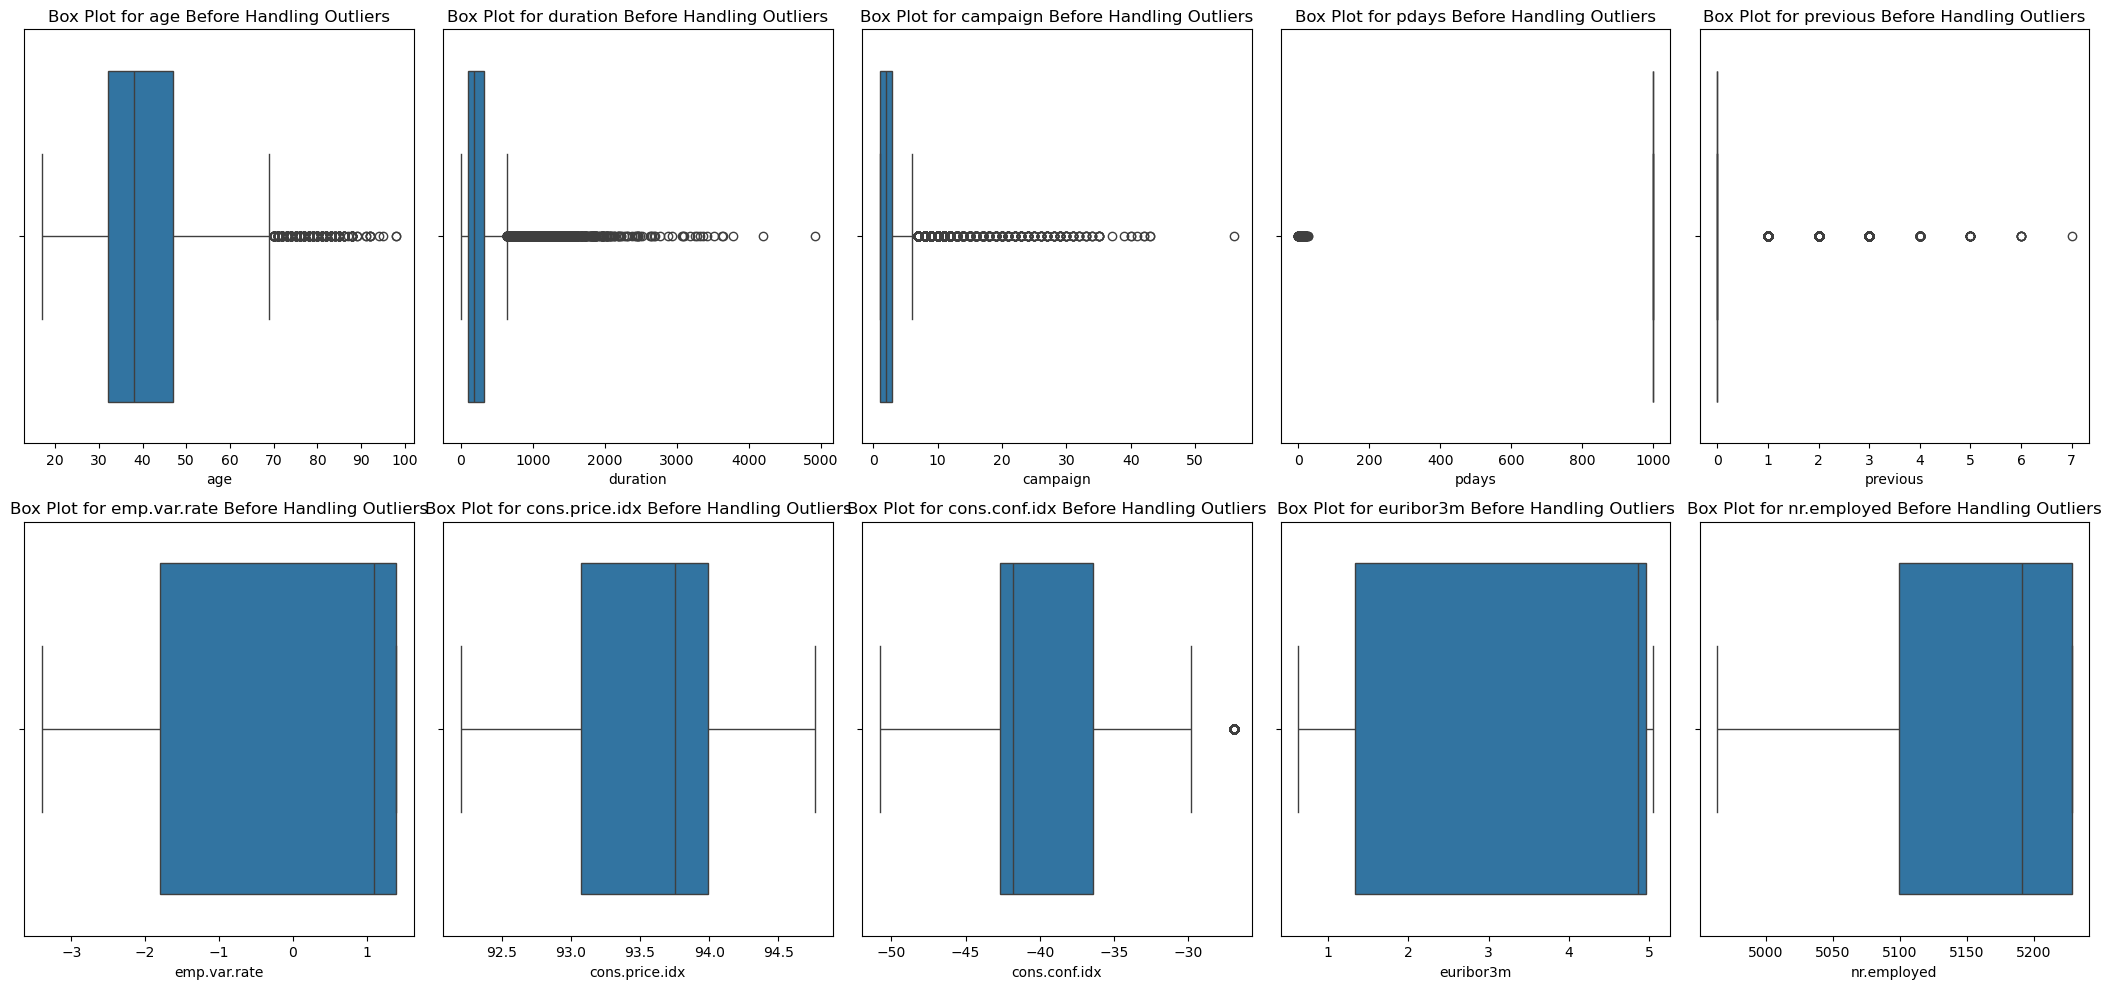

In [12]:
# Visualizing outliers using box plots before handling them
plot_box_plots(df, df.select_dtypes(include=['int64', 'float64']).columns, "Before Handling Outliers")

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
We can see that there are many outliers present in our dataset.
</p>
</div>

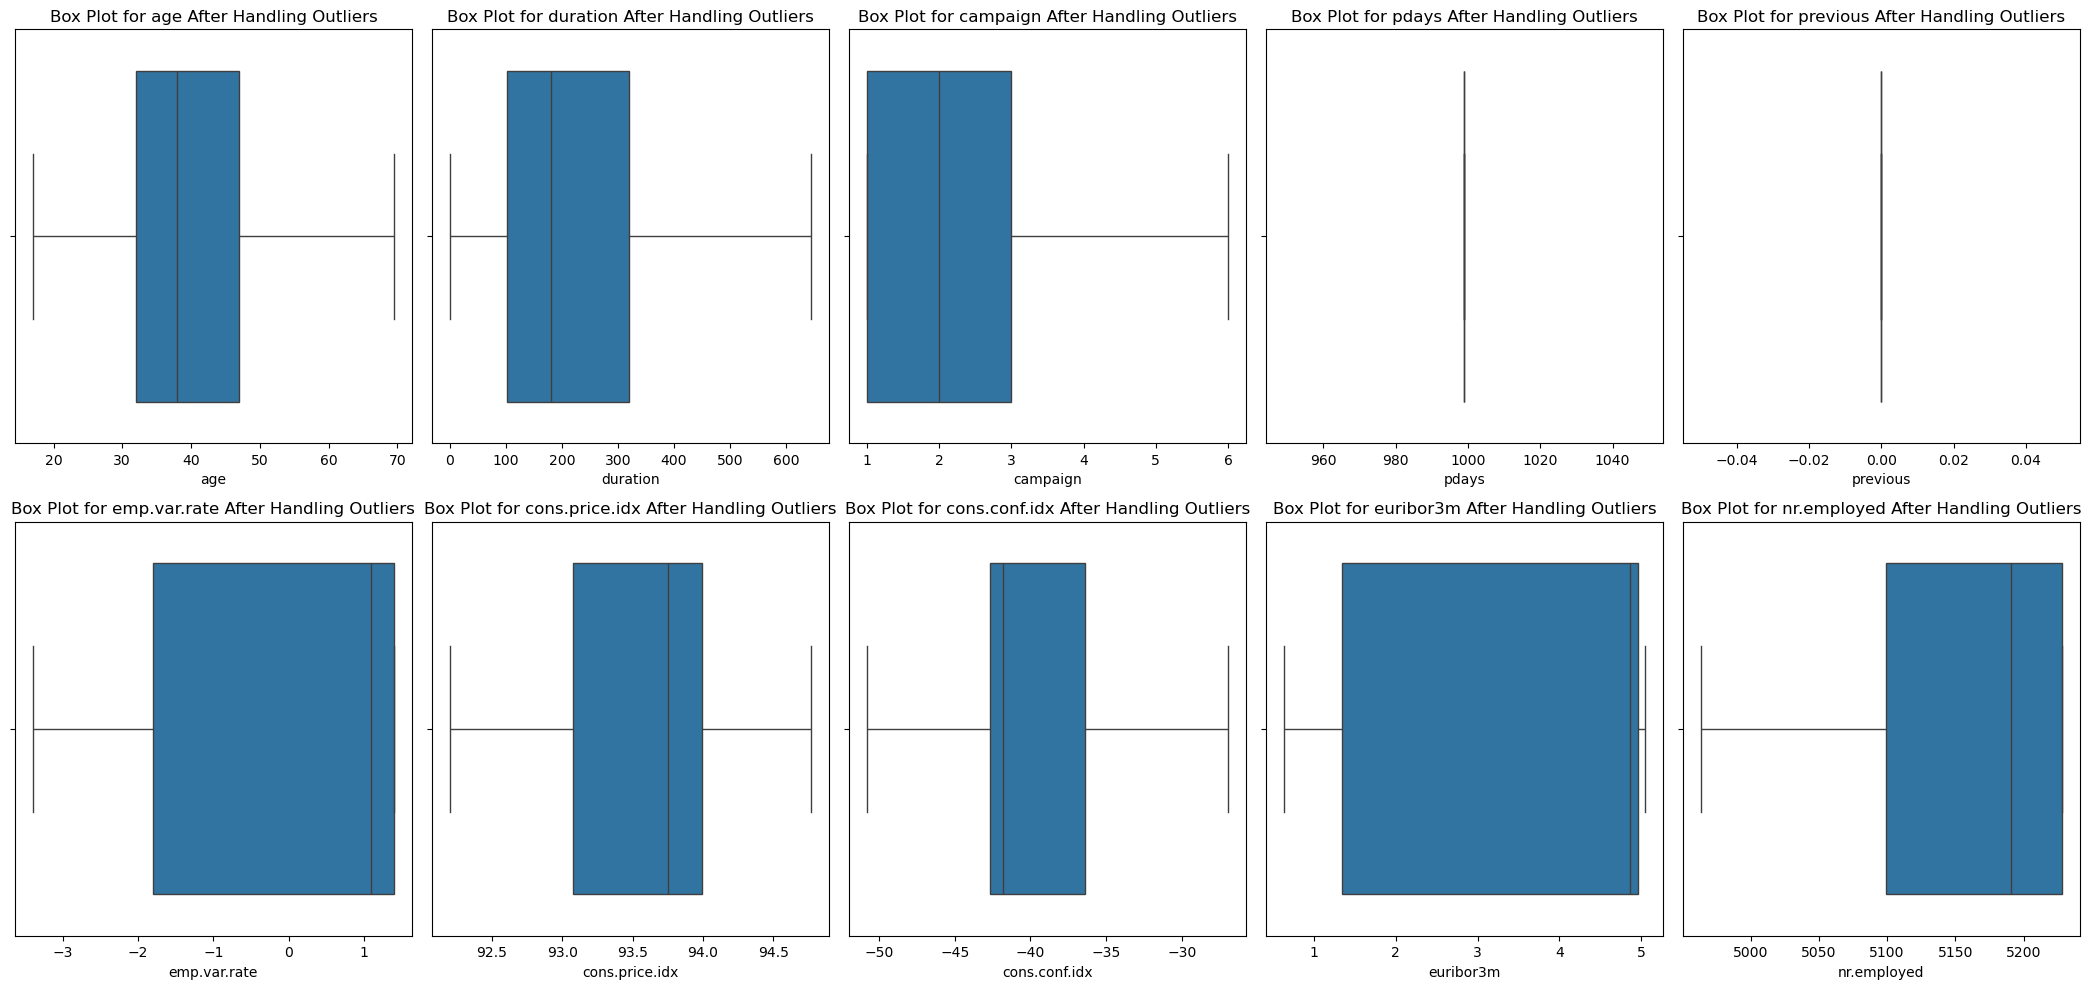

In [13]:
# Handling outliers for the numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    handle_outliers(df, col)

# Visualizing outliers using box plots after handling them
plot_box_plots(df, numerical_cols, "After Handling Outliers")

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Now that we have gotten rid of duplicates, outliers and any missing values. We can proceed to the next step, which is to explore the data for further analysis.
</p>
</div>

## **Exploratory Data Analysis**

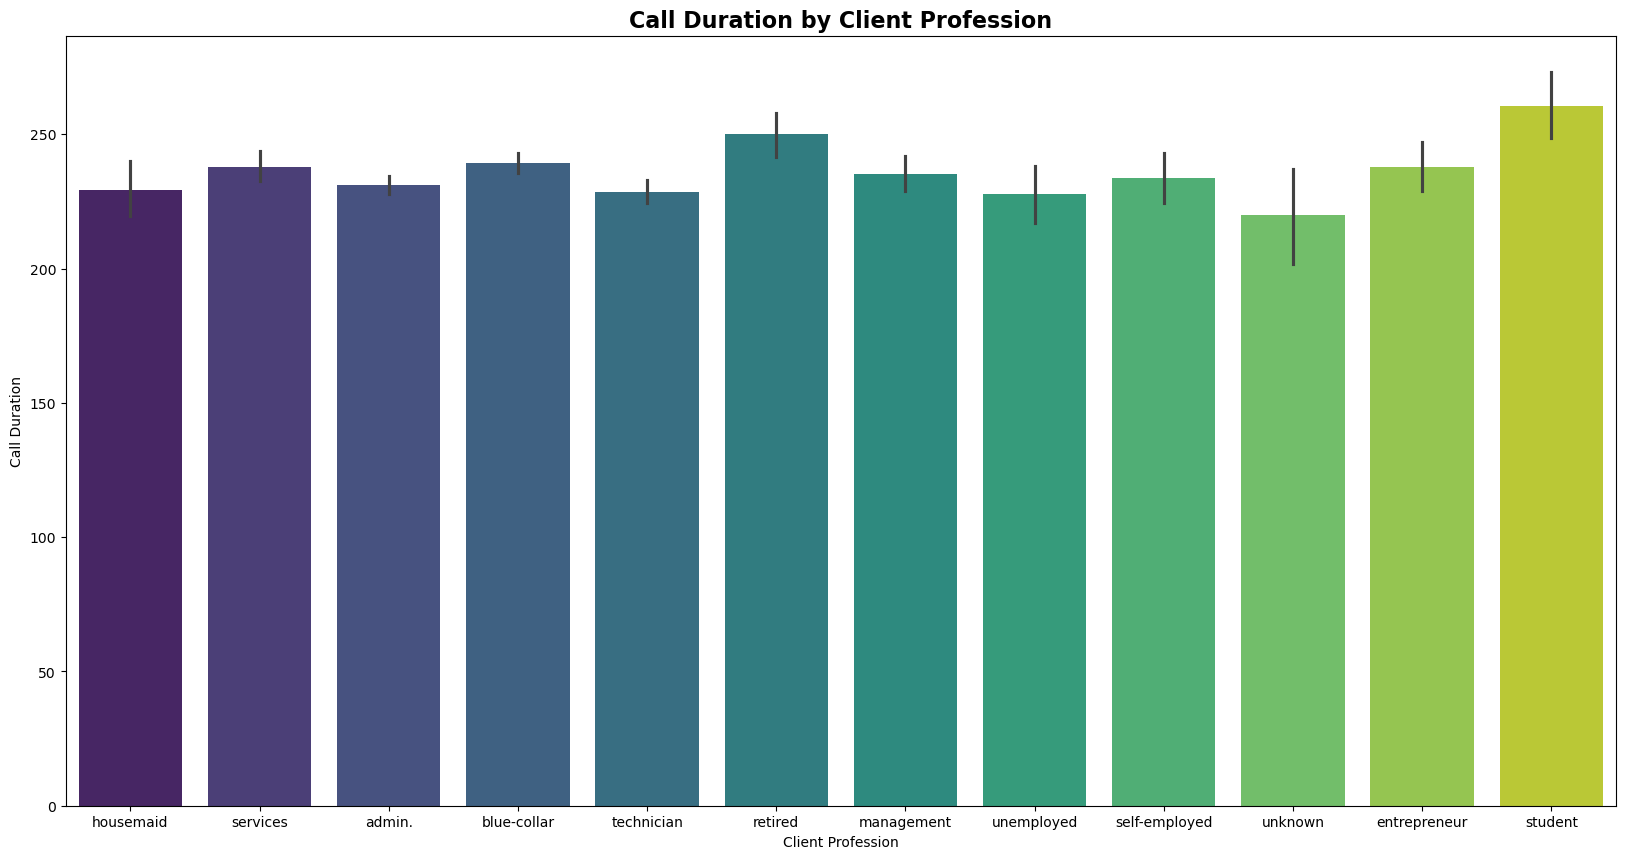

In [14]:
# Relationship between Job vs Duration
plt.figure(figsize=(20, 10))
sns.barplot(x='job', y='duration', data=df, hue='job', palette='viridis')
plt.title('Call Duration by Client Profession', fontsize=16, fontweight='bold')
plt.xlabel('Client Profession')
plt.ylabel('Call Duration')
plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
The bar chart shows the average call duration across different client professions. Students have the longest call durations, followed by retired and blue collar professions. unknown and technician workers have the shortest call durations. This suggests that call duration may vary significantly depending on the client's profession.
</p>
</div>

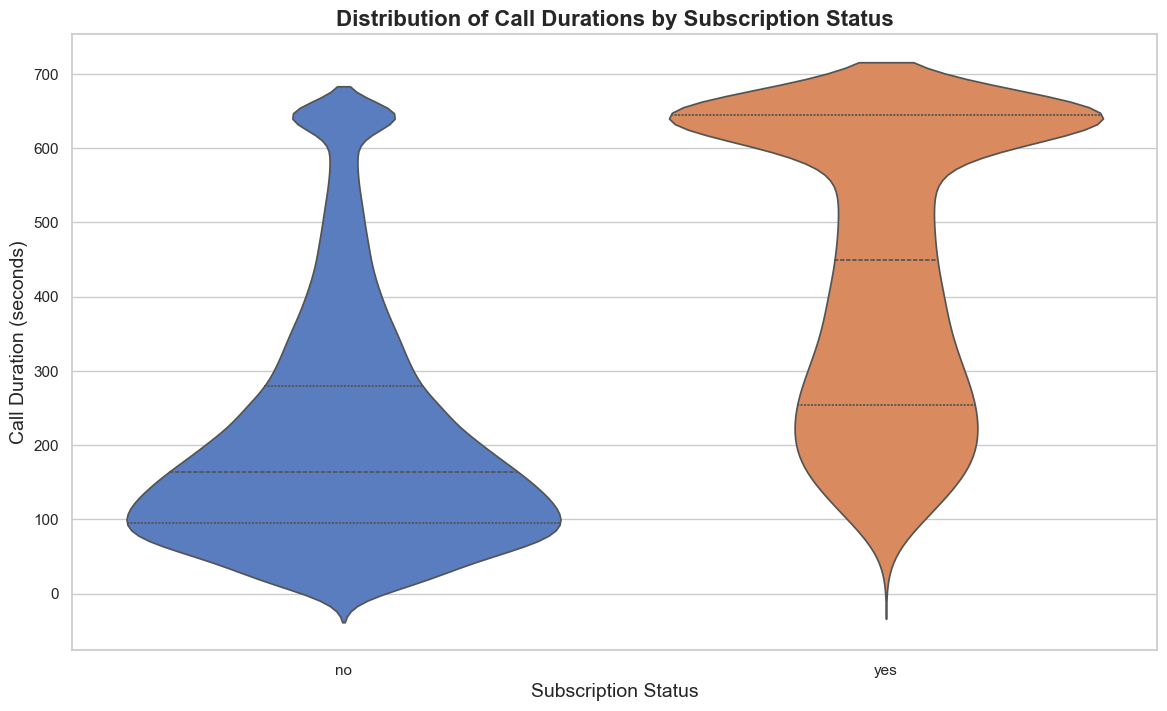

In [15]:
# Duration vs Subscribed

plt.figure(figsize=(14, 8))
sns.set(style='whitegrid')
sns.violinplot(x='subscribed', y='duration', data=df, inner='quartile', hue='subscribed', palette='muted')

# Enhancing labels and titles
plt.title('Distribution of Call Durations by Subscription Status', fontsize=16, fontweight='bold')
plt.xlabel('Subscription Status', fontsize=14)
plt.ylabel('Call Duration (seconds)', fontsize=14)

plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
The violin plot shows that subscribers generally have longer and more varied call durations compared to non-subscribers, whose calls are shorter and concentrated at lower durations. Longer call durations may indicate higher engagement and a greater likelihood of subscription.
</p>
</div>

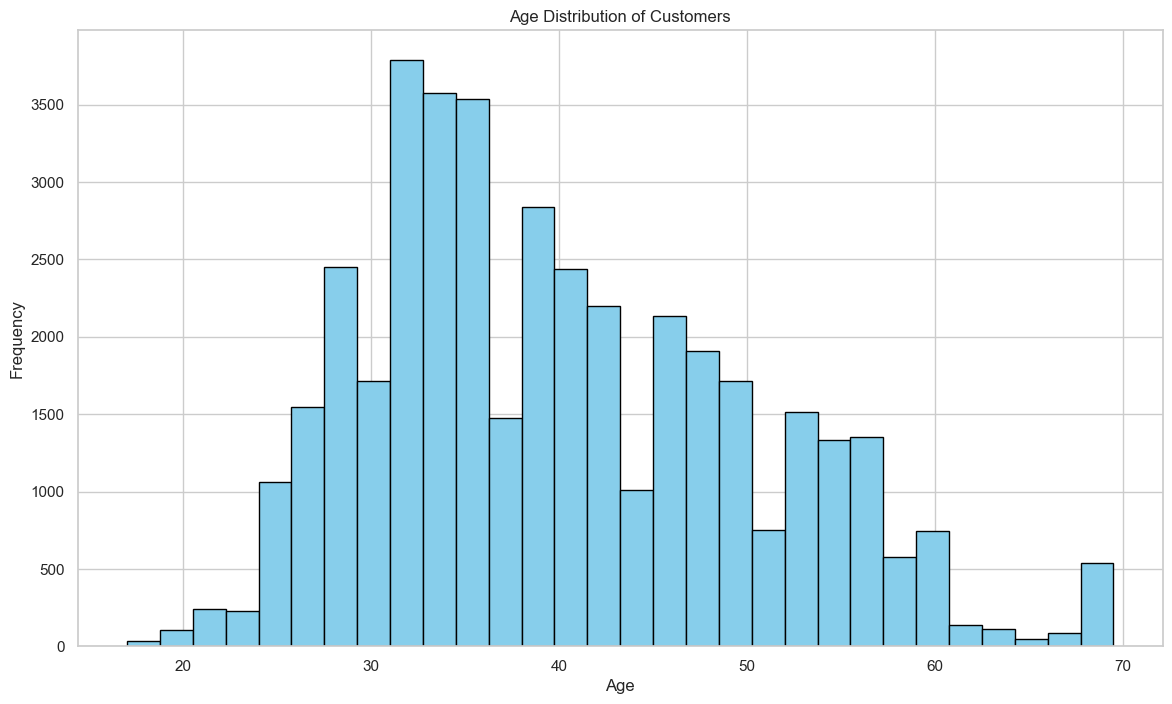

In [16]:
# Plot Age Distribution
plt.figure(figsize=(14, 8))
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
A histogram of customer ages indicated a broad age range, with the most common ages clustering around the middle-aged group which are 25, 40, and 55.
</p>
</div>

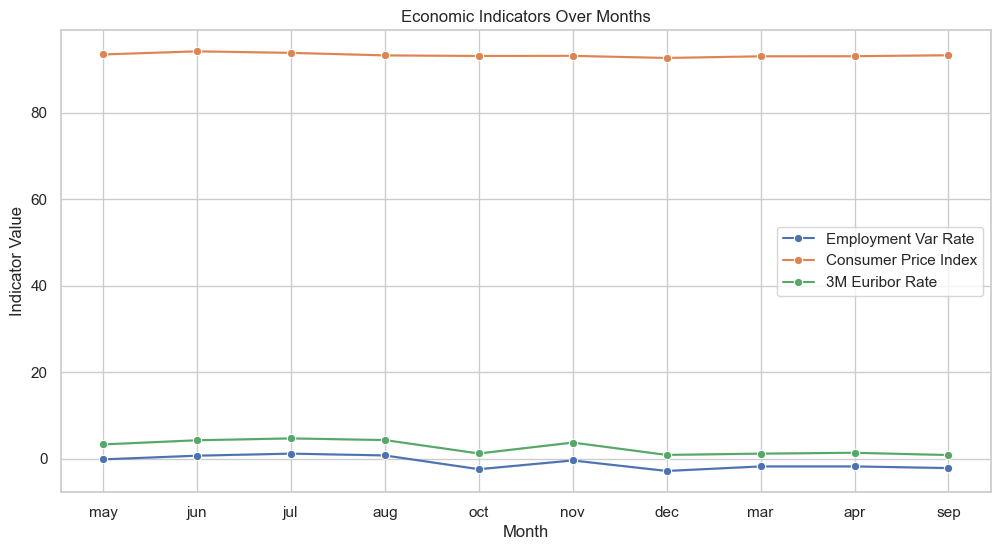

In [17]:
#Economic Indicators (emp.var.rate, cons.price.idx, euribor3m) by month
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='emp.var.rate', data=df, marker='o', label='Employment Var Rate')
sns.lineplot(x='month', y='cons.price.idx', data=df, marker='o', label='Consumer Price Index')
sns.lineplot(x='month', y='euribor3m', data=df, marker='o', label='3M Euribor Rate')

plt.title('Economic Indicators Over Months')
plt.xlabel('Month')
plt.ylabel('Indicator Value')
plt.legend()
plt.grid(True)
plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Line plots of employment variation rate, consumer price index, and the 3-month Euribor rate over the months highlighted significant fluctuations, particularly peaking in July and dropping sharply after August.
</p>
</div>

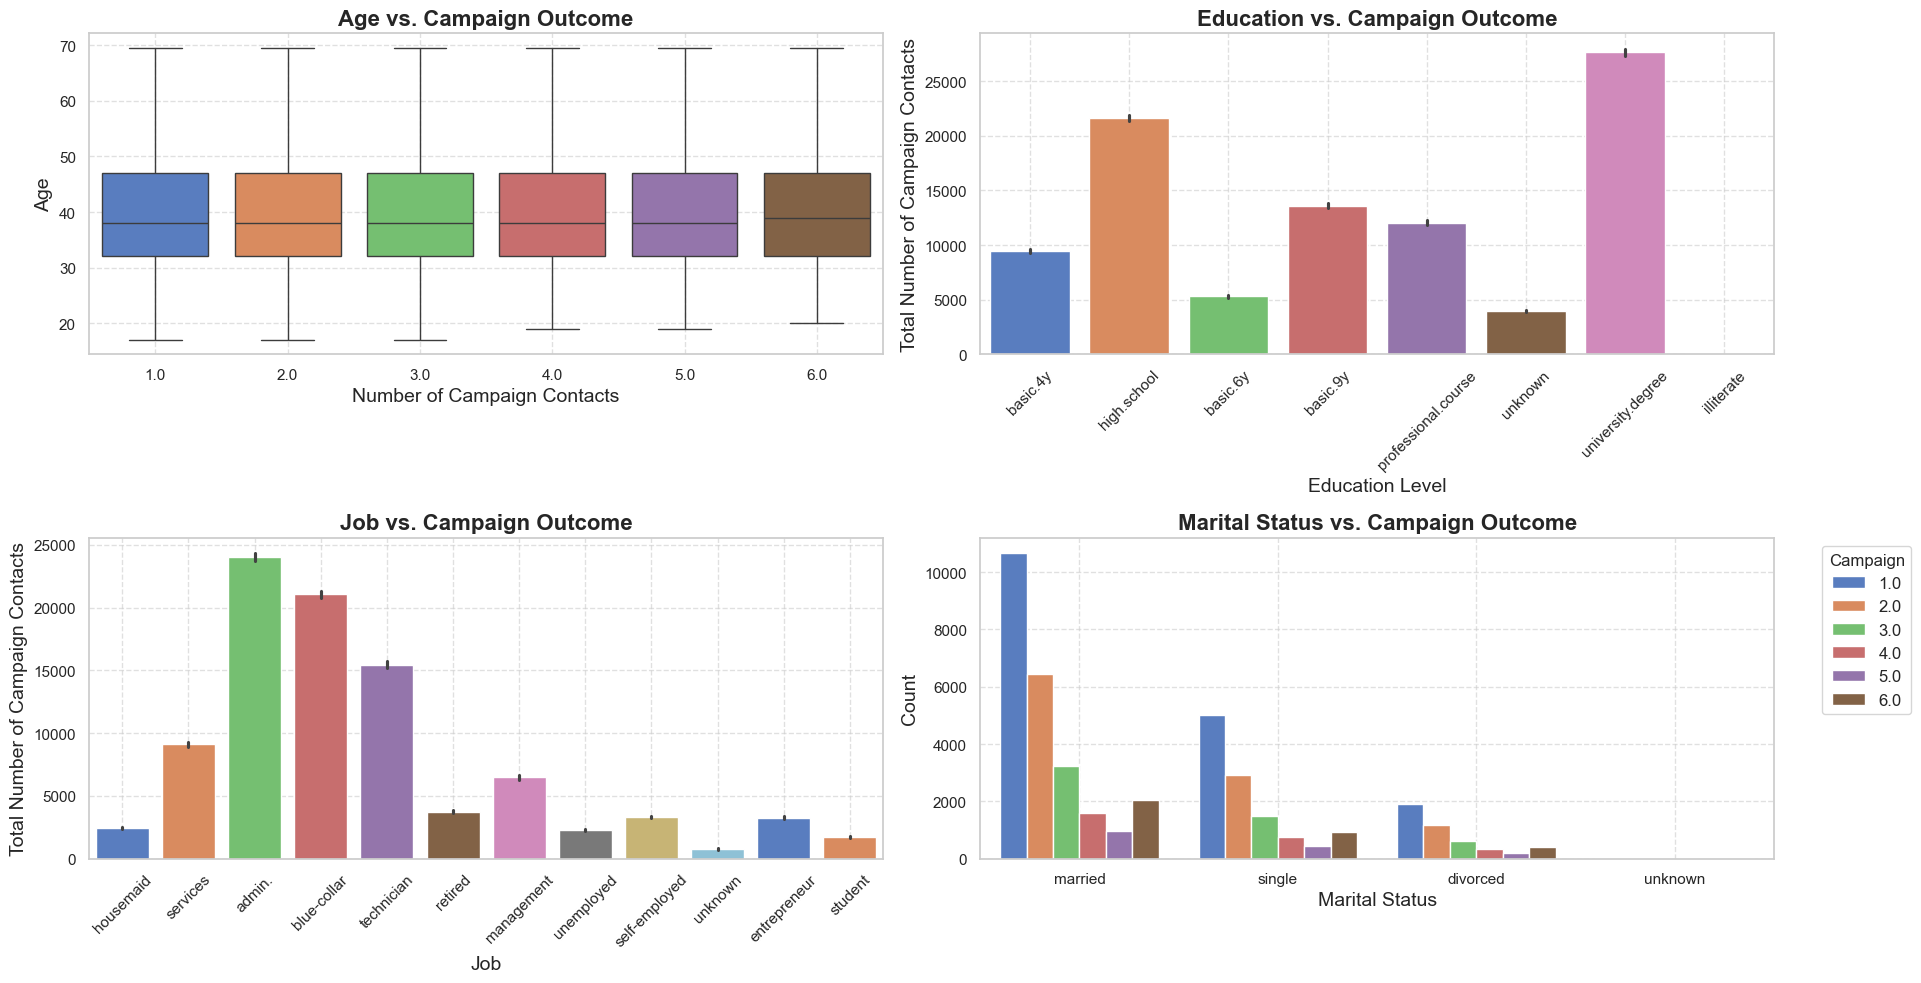

In [18]:
# Adjusting the palette based on the number of unique categories for the 'campaign' column
palette_campaign = sns.color_palette("muted", n_colors=df['campaign'].nunique())
palette_education = sns.color_palette("muted", n_colors=df['education'].nunique())
palette_job = sns.color_palette("muted", n_colors=df['job'].nunique())
palette_marital = sns.color_palette("muted", n_colors=df['campaign'].nunique())  # Match 'campaign' unique values

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: Age vs. Campaign Outcome
sns.boxplot(x='campaign', y='age', data=df, ax=axes[0, 0], hue='campaign', palette=palette_campaign, legend=False)
axes[0, 0].set_title('Age vs. Campaign Outcome', fontsize=16, fontweight='bold')
axes[0, 0].set_xlabel('Number of Campaign Contacts', fontsize=14)
axes[0, 0].set_ylabel('Age', fontsize=14)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Education vs. Campaign Outcome
sns.barplot(x='education', y='campaign', data=df, estimator=sum, ax=axes[0, 1], hue='education', palette=palette_education)
axes[0, 1].set_title('Education vs. Campaign Outcome', fontsize=16, fontweight='bold')
axes[0, 1].set_xlabel('Education Level', fontsize=14)
axes[0, 1].set_ylabel('Total Number of Campaign Contacts', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Job vs. Campaign Outcome
sns.barplot(x='job', y='campaign', data=df, estimator=sum, ax=axes[1, 0], hue='job', palette=palette_job)
axes[1, 0].set_title('Job vs. Campaign Outcome', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Job', fontsize=14)
axes[1, 0].set_ylabel('Total Number of Campaign Contacts', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Plot 4: Marital Status vs. Campaign Outcome
sns.countplot(x='marital', hue='campaign', data=df, palette=palette_marital, ax=axes[1, 1])
axes[1, 1].set_title('Marital Status vs. Campaign Outcome', fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel('Marital Status', fontsize=14)
axes[1, 1].set_ylabel('Count', fontsize=14)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Adjusting layout to prevent overlapping
plt.tight_layout()

# Move the legend outside the plots
plt.legend(title='Campaign', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=12)

plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
From these graphs, we can see that they provide valuable insights into the relationships between various demographic factors and campaign outcomes. The age distribution remains fairly consistent across different campaign contacts, indicating that age might not be a significant factor. However, education level shows a clear trend, with individuals holding a university degree receiving the most contacts, suggesting higher education levels influence campaign targeting. The job category analysis reveals that 'blue-collar' workers and those in management are frequently targeted, highlighting job type as a potential factor. Additionally, marital status analysis indicates that married individuals are contacted more often.
</p>
</div>

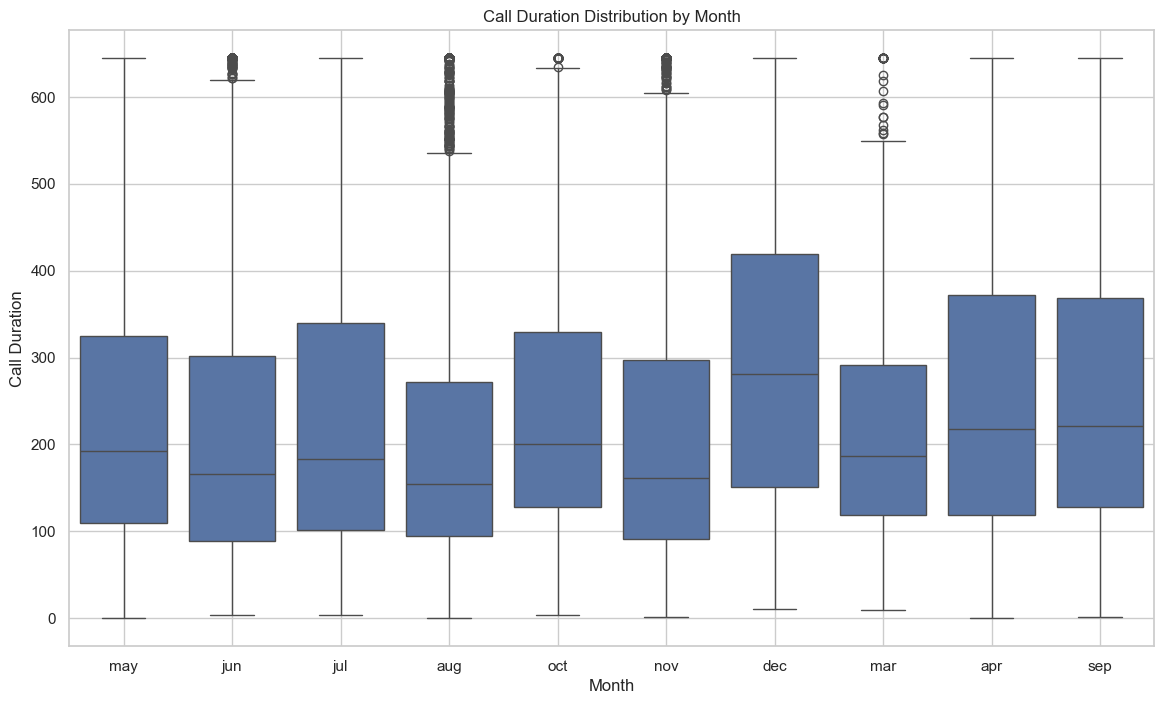

In [19]:
# Call Duration Distribution by Month
plt.figure(figsize=(14, 8))
sns.boxplot(x='month', y='duration', data=df)
plt.title('Call Duration Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Call Duration')
plt.grid(True)
plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Box plots show how call durations change each month. Most months have similar median call durations, but September and December have higher medians and more variation. Every month has outliers, very long calls that affect the distribution. May, June, and July have more similar call lengths, while April and December have a wider range of call durations, suggesting greater variability.
</p>
</div>

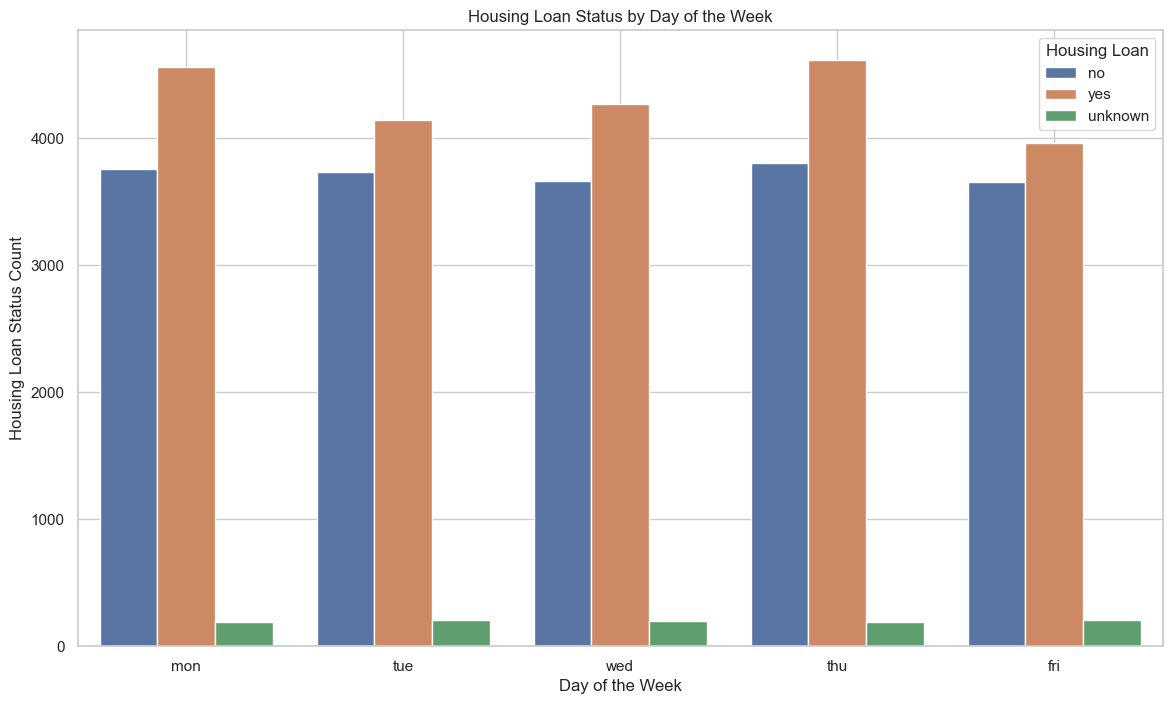

In [20]:
# Housing Loan Status by Day of the Week
plt.figure(figsize=(14, 8))
sns.countplot(x='day_of_week', hue='housing', data=df)
plt.title('Housing Loan Status by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Housing Loan Status Count')
plt.legend(title='Housing Loan')
plt.grid(True)
plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
For all days, the count of people with a "yes" status for a housing loan is consistently higher than those with "no." The "unknown" category has the least count across all days. The pattern is relatively consistent throughout the week.
</p>
</div>

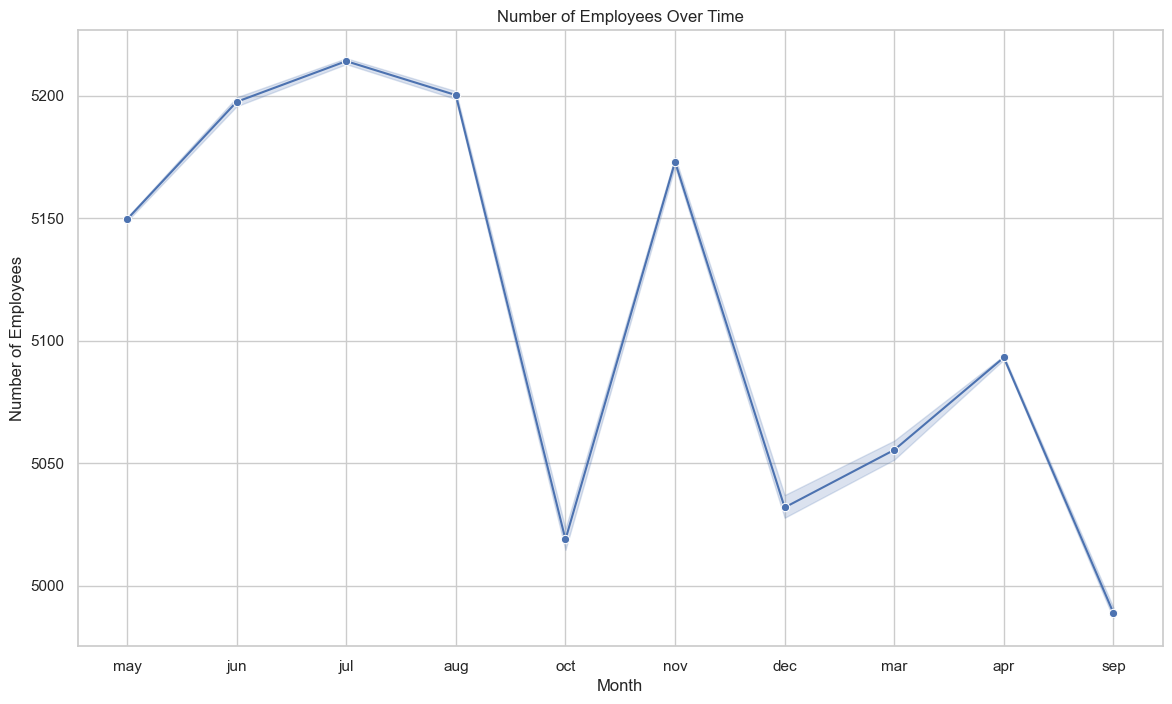

In [21]:
# Number of Employees Over Time
plt.figure(figsize=(14, 8))
sns.lineplot(x='month', y='nr.employed', data=df, marker='o')
plt.title('Number of Employees Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Employees')
plt.grid(True)
plt.show()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
A line plot depicted the number of employees over different months, showcasing employment trends.  Peaks are visible in July and November, while significant dips occur in October and December. This suggests seasonal trends in employment.
</p>
</div>

### **Summary Statistics**

In [22]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.000000,41176.000000,41176.000000,41176.0,41176.0,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,39.939236,235.021335,2.275476,999.0,0.0,0.081922,93.575720,-40.503405,3.621293,5167.034870
std,10.128801,177.365635,1.550606,0.0,0.0,1.570883,0.578839,4.626271,1.734437,72.251364
min,17.000000,0.000000,1.000000,999.0,0.0,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.0,0.0,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.0,0.0,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.0,0.0,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,69.500000,644.500000,6.000000,999.0,0.0,1.400000,94.767000,-26.950000,5.045000,5228.100000


### **Correlation Matrix of Numerical Features**

Text(0.5, 1.0, 'Heatmap of Correlation')

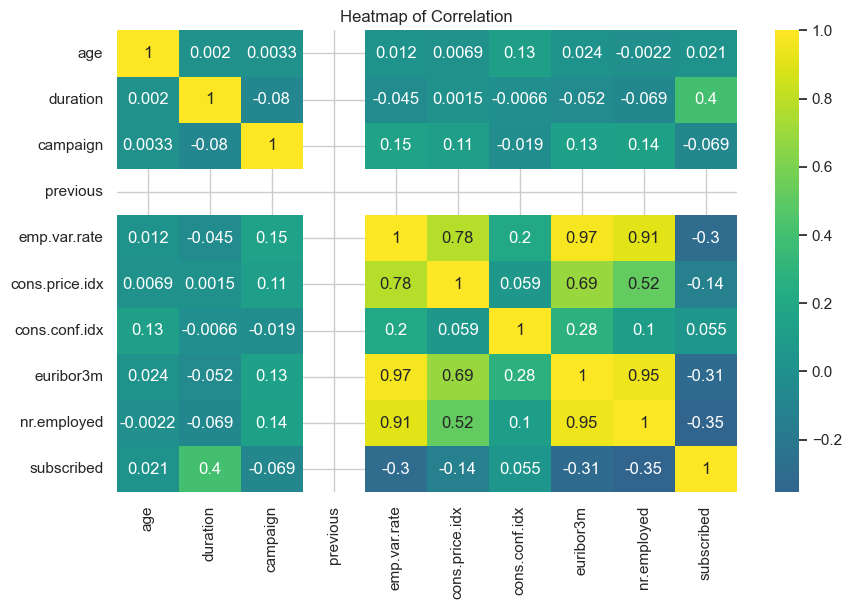

In [23]:
def cv (x):
  if x=="yes":
    return 1
  else:
    return 0
df1 = df.copy(deep=True)
subs = df1['subscribed']
subs1 = subs.apply(cv)
df1['subscribed'] = subs1
heat = df1[['age', 'duration', 'campaign',  'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed','subscribed']]
heat = heat.corr()
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(heat, center=0, cmap='viridis',annot=True)
ax.set_title("Heatmap of Correlation")

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
We visualized the correlation matrix to assess the relationships between numerical features and the target variable, subscribed. From the matrix, "Duration" shows a <strong>strong positive correlation (0.4)</strong> with "subscribed," indicating that longer call durations are associated with a higher likelihood of subscription. Features like "euribor3m" and "nr.employed" are <strong>highly correlated with each other (0.95)</strong>, suggesting redundancy, which may impact model performance due to multicollinearity. Several features, such as "age," "previous," and "cons.conf.idx," exhibit weak or negligible correlations with "subscribed," indicating limited predictive power on their own.
</p>
<p style='text-align: justify;'>
All features were retained for further analysis, as the dataset size and model selection allowed us to handle potentially less predictive features effectively. Feature selection was not explicitly performed in this project. Instead, we visualized a correlation matrix during EDA to understand feature relationships. All features were retained for modeling to preserve potential predictive signals.
</p>
</div>

## **Data Preprocessing Part 2 - Data Transformation**

In [24]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Before training the model, we need to transform the data. The first step is to separate the feature variables (X) and the target variable (y).
</p>
</div>

In [25]:
# Count the number of 1s in a specific column
count_of_yes = df['subscribed'].value_counts().get("yes", 0)

# Output the result
print(f"Number of 'yes' in the Column: {count_of_yes}")

Number of 'yes' in the Column: 4639


In [26]:
# Separate categorical and numerical columns
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Combine these features to define X, and encode the target variable y
X= df[categorical_cols + numerical_cols]
y= df['subscribed'].apply(lambda x: 1 if x == 'yes' else 0) # encode the target variable

# Apply One-Hot Encoding to the categorical variables to avoid the dummy variable trap
encoder = OneHotEncoder(sparse_output=False, drop='first')
categorical_encoded = encoder.fit_transform(X[categorical_cols])

# Normalize the numerical features using StandardScaler
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(X[numerical_cols])

# Combine the transformed categorical and numerical features
final_X = np.hstack((categorical_encoded, numerical_scaled))

## **Model Selection and Training**

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
After transforming the data, the next step is model selection and training.
</p>
</div>

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score, cross_val_predict

### **Data Splitting**

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Split the feature matrix (X) and the target variable (y) into training and testing sets.
</p>
</div>

In [28]:
# Split the data into training (80%) and testing sets (20%)
X_train, X_test, y_train, y_test = train_test_split(final_X, y, test_size=0.2, random_state=42, stratify=y)

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
This is the count for target variable '0' and '1' before the data being balanced. Next, we visualize the class distribution of the target variable in the training set.
</p>
</div>

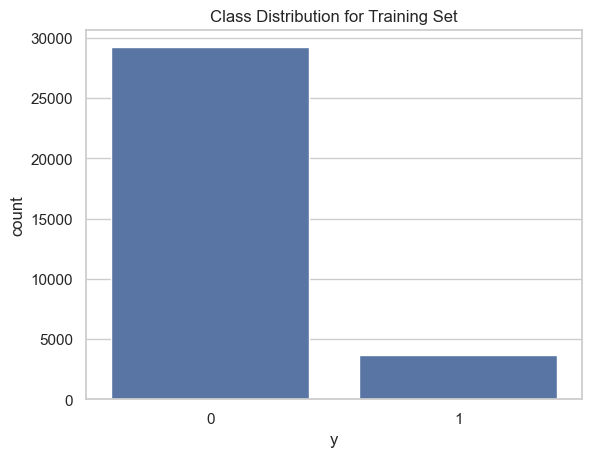

In [29]:
plt.figure()
sns.countplot(x='y', data = pd.DataFrame({'y':y_train}))
plt.title('Class Distribution for Training Set')
plt.show()

### **Handling Data Imbalance with SMOTE**

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
To address the imbalance in the target variable, apply SMOTE (Synthetic Minority Oversampling Technique).
</p>
</div>

In [30]:
# Using SMOTE techniques to handle data imbalancing
smote= SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled= smote.fit_resample(X_train, y_train)

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
This is the target variable after using SMOTE techniques. Next, we visualize the class distribution after applying SMOTE.
</p>
</div>

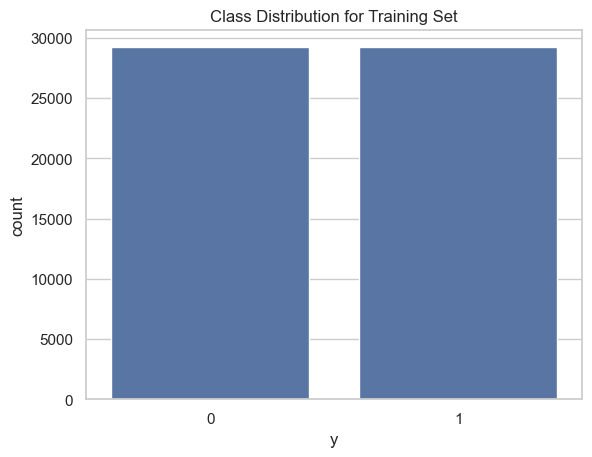

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [31]:
plt.figure()
sns.countplot(x='y', data = pd.DataFrame({'y':y_train_resampled}))
plt.title('Class Distribution for Training Set')
plt.show()
plt.figure()

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Before going for the result, we will apply for k-fold cross validation to make sure the results are more accurate.
</p>
</div>

### **Logistic Regression Cross-Validation**

<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Here we will perform k-fold cross-validation (e.g., k=5) for the Logistic Regression model we trained, and calculate the average AUC-ROC score.
</p>
</div>

In [32]:
# Initialize and train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Evaluate model
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Save results
results_lr = {
    "Classification Report": report_lr,
    "AUC-ROC": auc_lr
}

results_lr

{'Classification Report': {'0': {'precision': 0.9879479860450364,
   'recall': 0.8524904214559387,
   'f1-score': 0.9152343176142207,
   'support': 7308.0},
  '1': {'precision': 0.44145077720207254,
   'recall': 0.9181034482758621,
   'f1-score': 0.596221133659902,
   'support': 928.0},
  'accuracy': 0.8598834385624089,
  'macro avg': {'precision': 0.7146993816235545,
   'recall': 0.8852969348659003,
   'f1-score': 0.7557277256370614,
   'support': 8236.0},
  'weighted avg': {'precision': 0.9263708357528714,
   'recall': 0.8598834385624089,
   'f1-score': 0.8792891701264102,
   'support': 8236.0}},
 'AUC-ROC': np.float64(0.9361193979672725)}

In [33]:
# Perform k-fold cross-validation (e.g., k=5)
k = 5
cv_scores = cross_val_score(lr, X_train_resampled, y_train_resampled, cv=k, scoring='roc_auc')

# Average AUC-ROC score across all folds
mean_auc = cv_scores.mean()

print(f"AUC-ROC scores for each fold: {cv_scores}")
print(f"Mean AUC-ROC score: {mean_auc}")

AUC-ROC scores for each fold: [0.93933561 0.94011382 0.94114537 0.94050984 0.94205035]
Mean AUC-ROC score: 0.9406309991976624


### **Decision Tree Classifier Cross-Validation**
<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Here we will perform k-fold cross-validation (e.g., k=5) for the Decision Tree Classifier model we trained, and calculate the average AUC-ROC score.
</p>
</div>

In [34]:
# Initialize and train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

# Evaluate model
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
auc_dt = roc_auc_score(y_test, y_proba_dt)

# Save results
results_dt = {
    "Classification Report": report_dt,
    "AUC-ROC": auc_dt  # Decision Tree does not provide probabilities by default
}

results_dt

{'Classification Report': {'0': {'precision': 0.941012411100265,
   'recall': 0.9233716475095786,
   'f1-score': 0.9321085710339112,
   'support': 7308.0},
  '1': {'precision': 0.47417840375586856,
   'recall': 0.5441810344827587,
   'f1-score': 0.5067737079779228,
   'support': 928.0},
  'accuracy': 0.8806459446333171,
  'macro avg': {'precision': 0.7075954074280668,
   'recall': 0.7337763409961686,
   'f1-score': 0.719441139505917,
   'support': 8236.0},
  'weighted avg': {'precision': 0.8884113961882204,
   'recall': 0.8806459446333171,
   'f1-score': 0.8841835160416871,
   'support': 8236.0}},
 'AUC-ROC': np.float64(0.7337763409961686)}

In [35]:
# Perform k-fold cross-validation (k=5)
k = 5
cv_scores = cross_val_score(dt, X_train_resampled, y_train_resampled, cv=k, scoring='roc_auc')

# Average AUC-ROC score across all folds
mean_auc = cv_scores.mean()

print(f"AUC-ROC scores for each fold: {cv_scores}")
print(f"Mean AUC-ROC score: {mean_auc}")

AUC-ROC scores for each fold: [0.84014711 0.94184057 0.94371256 0.94500279 0.94780729]
Mean AUC-ROC score: 0.9237020659216049


### **Random Forest Classifier Cross-Validation**
<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Here we will perform k-fold cross-validation (e.g., k=5) for the Random Forest Classifier model we trained, and calculate the average AUC-ROC score.
</p>
</div>

In [36]:
# Initialize and train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate model
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Save results
results_rf = {
    "Classification Report": report_rf,
    "AUC-ROC": auc_rf
}

results_rf

{'Classification Report': {'0': {'precision': 0.9477285166940339,
   'recall': 0.9477285166940339,
   'f1-score': 0.9477285166940339,
   'support': 7308.0},
  '1': {'precision': 0.5883620689655172,
   'recall': 0.5883620689655172,
   'f1-score': 0.5883620689655172,
   'support': 928.0},
  'accuracy': 0.9072365225837785,
  'macro avg': {'precision': 0.7680452928297756,
   'recall': 0.7680452928297756,
   'f1-score': 0.7680452928297756,
   'support': 8236.0},
  'weighted avg': {'precision': 0.9072365225837785,
   'recall': 0.9072365225837785,
   'f1-score': 0.9072365225837785,
   'support': 8236.0}},
 'AUC-ROC': np.float64(0.9423484006662515)}

In [37]:
# Perform k-fold cross-validation (k=5)
k = 5
cv_scores = cross_val_score(rf, X_train_resampled, y_train_resampled, cv=k, scoring='roc_auc')

# Average AUC-ROC score across all folds
mean_auc = cv_scores.mean()

print(f"AUC-ROC scores for each fold: {cv_scores}")
print(f"Mean AUC-ROC score: {mean_auc}")

AUC-ROC scores for each fold: [0.98288321 0.99849411 0.99840862 0.99823742 0.99877238]
Mean AUC-ROC score: 0.9953591492820971


### **Gradient Boosting Classifier Cross-Validation**
<div style='line-height: 1.8;'>
<p style='text-align: justify;'>
Here we will perform k-fold cross-validation (e.g., k=5) for the Gradient Boosting Classifier model we trained, and calculate the average AUC-ROC score.
</p>
</div>

In [38]:
# Initialize and train Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

# Evaluate model
report_gb = classification_report(y_test, y_pred_gb, output_dict=True)
auc_gb = roc_auc_score(y_test, y_proba_gb)

# Save results
results_gb = {
    "Classification Report": report_gb,
    "AUC-ROC": auc_gb
}

results_gb

{'Classification Report': {'0': {'precision': 0.9763533610945866,
   'recall': 0.8983305966064586,
   'f1-score': 0.9357183580387686,
   'support': 7308.0},
  '1': {'precision': 0.5085978835978836,
   'recall': 0.8286637931034483,
   'f1-score': 0.6303278688524591,
   'support': 928.0},
  'accuracy': 0.8904808159300631,
  'macro avg': {'precision': 0.7424756223462351,
   'recall': 0.8634971948549535,
   'f1-score': 0.7830231134456138,
   'support': 8236.0},
  'weighted avg': {'precision': 0.9236485185597468,
   'recall': 0.8904808159300631,
   'f1-score': 0.9013081620741139,
   'support': 8236.0}},
 'AUC-ROC': np.float64(0.9419162160504313)}

In [39]:
# Perform k-fold cross-validation (k=5)
k = 5
cv_scores = cross_val_score(gb, X_train_resampled, y_train_resampled, cv=k, scoring='roc_auc')

# Average AUC-ROC score across all folds
mean_auc = cv_scores.mean()

print(f"AUC-ROC scores for each fold: {cv_scores}")
print(f"Mean AUC-ROC score: {mean_auc}")

AUC-ROC scores for each fold: [0.95892772 0.99149891 0.99118969 0.99104454 0.99164532]
Mean AUC-ROC score: 0.9848612348304624


## **Hyperparameter Tuning**

### **Logistic Regression Parameters**

**solver**: Algorithm to use in the optimization problem. {‘lbfgs’, ‘liblinear’, ‘newton-cg’, ‘newton-cholesky’, ‘sag’, ‘saga’}
<br>
- For small datasets, **'liblinear'** is a good choice, whereas **'sag'** and **'saga'** are faster for large ones.
- For multiclass problems, all solvers except **'liblinear'** minimize the full multinomial loss.
- **'newton-cholesky'** is a good choice for n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories.
<br>

**penalty**: Specify the norm of the penalty. {'l1', 'l2', 'elasticnet'}
<br>
- **l1**: add a L1 penalty term.
- **l2**: add a L2 penalty term.
- **elasticnet**: both L1 and L2 penalty terms are added.
<br>

Pekhimenko (2006) stated that employing logistic regression without additional regularization does not guarantee satisfactory results due to potential over-fitting. This often happens when the number of observations or training examples (m) is insufficiently large in comparison to the number of feature variables (n). To get a reliable classifier, some form of regularizer is required. One of the way is using penalization.
<br>

**C**: Inverse of regularization strength; must be a positive float. Smaller values specify stronger regularization. The C parameter in logistic regression models acts as a control for the amount of regularization. It determines how much the model is penalized for increasing the magnitude of parameter values, with the goal of preventing overfitting.
<br>

**max_iter**: Maximum number of iterations taken for the solvers to converge.
<br>

**l1_ratio**: The Elastic-Net mixing parameter, with 0 <= l1_ratio <= 1. Only used if penalty='elasticnet'. Setting l1_ratio=0 is equivalent to using penalty='l2', while setting l1_ratio=1 is equivalent to using penalty='l1'. For 0 < l1_ratio < 1, the penalty is a combination of L1 and L.
<br>

---

Reference:
<br>
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression
<br>
- Pekhimenko, G. (2006). Penalizied logistic regression for classification. Dept. Comput. Sci.., Univ. Toronto, Toronto, ON M5S3L1.

### **Decision Tree Classifier Parameters**

**criterion**: The function to measure the quality of a split. {'gini', 'entropy', 'log_loss'}
<br>
- Supported criteria are **'gini'** for the Gini impurity and **'log_loss'** and **'entropy'** both for the Shannon information gain.
<br>

**max_depth**: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
<br>

**min_samples_split**: The minimum number of samples required to split an internal node. **min_samples_split** is used to control over-fitting. Higher values prevent a model from learning relations which might be highly specific to the particular sample selected for a tree. Too high values can also lead to under-fitting.
<br>
- If int, then consider min_samples_split as the minimum number.
- If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.
<br>

**min_samples_leaf**: The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least **min_samples_leaf** training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.
<br>
- If int, then consider min_samples_leaf as the minimum number.
- If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.
<br>

**max_features**: The number of features to consider when looking for the best split. int, float or {'sqrt', 'log2'}
<br>
- If int, then consider max_features features at each split.
- If float, then max_features is a fraction and max(1, int(max_features * n_features_in_)) features are considered at each split.
- If 'sqrt', then max_features=sqrt(n_features).
- If 'log2', then max_features=log2(n_features).
- If None, then max_features=n_features.
<br>

**max_leaf_nodes**: Grow a tree with **max_leaf_nodes** in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes. Setting this parameter helps control the model's complexity and prevent overfitting.
<br>

---

Reference:
<br>
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
<br>
- https://towardsdatascience.com/how-to-tune-a-decision-tree-f03721801680
<br>


### **Random Forest Classifier Parameters**

**n_estimators**: The number of trees in the forest.
<br>

**max_features**: The number of features to consider when looking for the best split. {'sqrt', 'log2', None}
<br>
- If int, then consider max_features features at each split.
- If float, then max_features is a fraction and max(1, int(max_features * n_features_in_)) features are considered at each split.
- If 'sqrt', then max_features=sqrt(n_features).
- If 'log2', then max_features=log2(n_features).
- If None, then max_features=n_features.
<br>

**max_depth**: The number of features to consider when looking for the best split.
<br>

**min_samples_split**: The minimum number of samples required to split an internal node.
<br>
- If int, then consider min_samples_split as the minimum number.
- If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.
<br>

**min_samples_leaf**: The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.
<br>
- If int, then consider min_samples_leaf as the minimum number.
- If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.
<br>

**bootstrap**: Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
<br>

---

Reference:
<br>
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
<br>
- https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

### **Gradient Boosting Classifier Parameters**

**n_estimators**: The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.
<br>

**min_samples_split**: The minimum number of samples required to split an internal node.
<br>
- If int, values must be in the range [2, inf).
- If float, values must be in the range (0.0, 1.0] and min_samples_split will be ceil(min_samples_split * n_samples).
<br>

**min_samples_leaf**: The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.
<br>
- If int, values must be in the range [1, inf).
- If float, values must be in the range (0.0, 1.0) and min_samples_leaf will be ceil(min_samples_leaf * n_samples).
<br>

**max_depth**: Maximum depth of the individual regression estimators. The maximum depth limits the number of nodes in the tree. Tune this parameter for best performance; the best value depends on the interaction of the input variables. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. If int, values must be in the range [1, inf).
<br>

**max_features**: The number of features to consider when looking for the best split.
<br>
- If int, values must be in the range [1, inf).
- If float, values must be in the range (0.0, 1.0] and the features considered at each split will be max(1, int(max_features * n_features_in_)).
- If 'sqrt', then max_features=sqrt(n_features).
- If 'log2', then max_features=log2(n_features).
- If None, then max_features=n_features.
<br>

**subsample**: The fraction of samples to be used for fitting the individual base learners. If smaller than 1.0 this results in Stochastic Gradient Boosting. subsample interacts with the parameter n_estimators. Choosing subsample < 1.0 leads to a reduction of variance and an increase in bias. Values must be in the range (0.0, 1.0].
<br>

**learning_rate**: Learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators. Values must be in the range [0.0, inf).

---

Reference:
<br>
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html


### **Defining the Parameters Grid for Each Model**

In [40]:
lr_params = [
    # Solvers Compatible with 'l2' and None Penalties
    {
        'solver': ['lbfgs', 'newton-cg', 'sag', 'newton-cholesky'],
        'penalty': ['l2', None],
        'C': [1.0, 0.1, 0.01],
        'max_iter': [100, 300, 500]
    },
    # Solvers Compatible with 'l1' and 'l2' Penalties
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [1.0, 0.1, 0.01],
        'max_iter': [100, 300, 500]
    },
    # Solvers Compatible with 'l1', 'l2', and 'elasticnet' Penalties
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [1.0, 0.1, 0.01],
        'l1_ratio': [0.1, 0.5],
        'max_iter': [100, 300, 500]
    }
]

In [41]:
dt_params = [
    {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 10, 20, 30, 40],    # Control tree depth
        'min_samples_split': [2, 5, 10, 20],    # Minimum samples for splitting
        'min_samples_leaf': [1, 2, 4, 10],      # Minimum samples per leaf
        'max_features': [None, 'sqrt', 'log2'], # Features to consider at each split
        'max_leaf_nodes': [None, 10, 20, 50]    # Control the number of leaf nodes
    }
]

In [42]:
rf_params = [
    {
        'n_estimators': [100, 200],             # Number of trees
        'max_depth': [None, 10, 20],            # Maximum depth of each tree
        'min_samples_split': [2, 5],            # Minimum samples required for splitting
        'min_samples_leaf': [1, 2],             # Minimum samples per leaf
        'max_features': ['sqrt', 'log2'],       # Features to consider at each split
        'bootstrap': [True, False]              # Use of bootstrap sampling
    }
]

In [43]:
gb_params = [
    {
        'n_estimators': [100, 200],             # Number of trees
        'learning_rate': [0.01, 0.05, 0.1],     # Learning rate
        'max_depth': [3, 5],                    # Maximum tree depth
        'min_samples_split': [2, 5],            # Minimum samples to split
        'min_samples_leaf': [1, 2],             # Minimum samples per leaf
        'subsample': [0.8, 1.0],                # Subsampling fraction
        'max_features': ['sqrt']                # Number of features to consider
    }
]

### **Tuning the Models - RandomizedSearchCV**

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

import time
from datetime import timedelta

In [45]:
# Perform randomized search cross-validation for a given estimator and measure execution time.
def perform_randomized_search(estimator, param_grid, X_train, y_train, model_name, cv=5, scoring='accuracy', random_state=42):
    # Create and fit RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        scoring=scoring,
        cv=cv,     # Determines the cross-validation splitting strategy.
        n_jobs=-1, # Number of CPU cores Used
        n_iter=20, # Number of Parameter Settings that are Sampled
        random_state=random_state,
        verbose=1  # Show progress
    )

    # Start timing
    print(f"\n{'='*50}")
    print(f"Starting RandomizedSearchCV for {model_name}...")
    start_time = time.time()

    # Fit the model
    random_result = random_search.fit(X_train, y_train)

    # Calculate execution time
    end_time = time.time()
    execution_time = end_time - start_time

    # Format time for display
    time_str = str(timedelta(seconds=int(execution_time)))

    # Print results
    print(f"\nRandomizedSearchCV for {model_name} completed!")
    print(f"Time Taken: {time_str} (or {execution_time:.2f} seconds)")
    print(f"Best Parameters: {random_result.best_params_}")
    print(f"Best {scoring}: {random_result.best_score_:.4f}")
    print(f"{'='*50}\n")
    
    return random_result

In [46]:
# RandomizedSearchCV for Logistic Regression
lr_random_result = perform_randomized_search(LogisticRegression(random_state=42), lr_params, 
                                             X_train_resampled, y_train_resampled, "Logistic Regression")


Starting RandomizedSearchCV for Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomizedSearchCV for Logistic Regression completed!
Time Taken: 0:00:15 (or 15.03 seconds)
Best Parameters: {'solver': 'lbfgs', 'penalty': None, 'max_iter': 300, 'C': 1.0}
Best accuracy: 0.8861



In [47]:
# RandomizedSearchCV for Decision Tree
dt_random_result = perform_randomized_search(DecisionTreeClassifier(random_state=42), dt_params, 
                                             X_train_resampled, y_train_resampled, "Decision Tree")


Starting RandomizedSearchCV for Decision Tree...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomizedSearchCV for Decision Tree completed!
Time Taken: 0:00:04 (or 4.23 seconds)
Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 40, 'criterion': 'gini'}
Best accuracy: 0.9195



In [48]:
# RandomizedSearchCV for Random Forest
rf_random_result = perform_randomized_search(RandomForestClassifier(random_state=42), rf_params, 
                                             X_train_resampled, y_train_resampled, "Random Forest")


Starting RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomizedSearchCV for Random Forest completed!
Time Taken: 0:02:25 (or 145.16 seconds)
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Best accuracy: 0.9535



In [49]:
# RandomizedSearchCV for Gradient Boosting
gb_random_result = perform_randomized_search(GradientBoostingClassifier(random_state=42), gb_params, 
                                             X_train_resampled, y_train_resampled, "Gradient Boosting")


Starting RandomizedSearchCV for Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomizedSearchCV for Gradient Boosting completed!
Time Taken: 0:02:10 (or 130.99 seconds)
Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.1}
Best accuracy: 0.9269



### **Tuning the Models - GridSearchCV**

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
# Perform grid search cross-validation for a given estimator and measure execution time.
def perform_grid_search(estimator, param_grid, X_train, y_train, model_name, cv=5, scoring='accuracy', random_state=42):
    # Create and fit GridSearchCV
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,     # Determines the cross-validation splitting strategy.
        n_jobs=-1, # Number of CPU cores Used
        verbose=1  # Show progress
    )

    # Start timing
    print(f"\n{'='*50}")
    print(f"Starting GridSearchCV for {model_name}...")
    start_time = time.time()

    # Fit the model
    grid_result = grid_search.fit(X_train, y_train)

    # Calculate execution time
    end_time = time.time()
    execution_time = end_time - start_time

    # Format time for display
    time_str = str(timedelta(seconds=int(execution_time)))

    # Print results
    print(f"\nGridSearchCV for {model_name} completed!")
    print(f"Time Taken: {time_str} (or {execution_time:.2f} seconds)")
    print(f"Best Parameters: {grid_result.best_params_}")
    print(f"Best {scoring}: {grid_result.best_score_:.4f}")
    print(f"{'='*50}\n")
    
    return grid_result

In [52]:
# GridSearchCV for Logistic Regression
lr_grid_result = perform_grid_search(LogisticRegression(random_state=42), lr_params, 
                                     X_train_resampled, y_train_resampled, "Logistic Regression")


Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 144 candidates, totalling 720 fits


C:\Anaconda3\envs\CDS6314\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



GridSearchCV for Logistic Regression completed!
Time Taken: 0:02:07 (or 127.30 seconds)
Best Parameters: {'C': 1.0, 'max_iter': 100, 'penalty': None, 'solver': 'lbfgs'}
Best accuracy: 0.8861



In [53]:
# GridSearchCV for Decision Tree
dt_grid_result = perform_grid_search(DecisionTreeClassifier(random_state=42), dt_params, 
                                     X_train_resampled, y_train_resampled, "Decision Tree")


Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 2880 candidates, totalling 14400 fits

GridSearchCV for Decision Tree completed!
Time Taken: 0:07:44 (or 464.85 seconds)
Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best accuracy: 0.9248



In [54]:
# GridSearchCV for Random Forest
rf_grid_result = perform_grid_search(RandomForestClassifier(random_state=42), rf_params, 
                                     X_train_resampled, y_train_resampled, "Random Forest")


Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

GridSearchCV for Random Forest completed!
Time Taken: 0:11:12 (or 672.42 seconds)
Best Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best accuracy: 0.9561



In [55]:
# GridSearchCV for Gradient Boosting
gb_grid_result = perform_grid_search(GradientBoostingClassifier(random_state=42), gb_params, 
                                     X_train_resampled, y_train_resampled, "Gradient Boosting")


Starting GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

GridSearchCV for Gradient Boosting completed!
Time Taken: 0:10:20 (or 620.79 seconds)
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}
Best accuracy: 0.9281



## **Model Evaluation and Comparison**

In [56]:
# Importing Required Library
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay

In [57]:
# Evaluate a classification model with multiple metrics and optional visualizations.
def evaluate_model(model, X_test, y_test, model_name, plot_figures=True, return_metrics=True):
    # Get predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)

    # Calculate confusion matrix and specificity
    cm = confusion_matrix(y_test, y_pred)
    TN = cm[0, 0]  # True Negatives
    FP = cm[0, 1]  # False Positives
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Print results
    print(f"\n{'-'*20} {model_name} Evaluation {'-'*20}")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Sensitivity/Recall: {sensitivity:.4f}")
    print(f"Specificity:        {specificity:.4f}")
    print(f"F1-Score:           {f1:.4f}")
    print(f"AUC-ROC:            {auc:.4f}")

    # Plotting if requested
    if plot_figures:
        # Plotting the Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        cm_display.plot(cmap='Blues', values_format='d')  # Use d for integer formatting
        cm_display.ax_.set_title(f"ROC Curve for {model_name}")
        
        # Plotting the ROC Curve
        RocCurveDisplay.from_predictions(y_test, y_proba)
    
    # Return metrics if requested
    if return_metrics:
        metrics = {
            'name': model_name,
            'accuracy': accuracy,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'f1_score': f1,
            'auc': auc,
            'confusion_matrix': cm
        }
        return metrics

In [58]:
# Create a comparison dataframe from a list of metrics dictionaries
def compare_models(metrics_list):
    comparison_df = pd.DataFrame([
        {
            'Model': m['name'],
            'Accuracy': m['accuracy'],
            'Sensitivity': m['sensitivity'],
            'Specificity': m['specificity'],
            'F1-Score': m['f1_score'],
            'AUC-ROC': m['auc']
        } for m in metrics_list
    ])

    # Format as percentages
    for col in ['Accuracy', 'Sensitivity', 'Specificity', 'F1-Score', 'AUC-ROC']:
        comparison_df[col] = comparison_df[col].map('{:.2%}'.format)

    # Highlight the best value in each column
    styled_df = comparison_df.style.highlight_max(
        subset=['Accuracy', 'Sensitivity', 'Specificity', 'F1-Score', 'AUC-ROC'],
        color='lightgreen'
    )
    
    return styled_df

### **Evaluating Baseline Models**


-------------------- Logistic Regression (Base) Evaluation --------------------
Accuracy:           0.8599
Sensitivity/Recall: 0.9181
Specificity:        0.8525
F1-Score:           0.5962
AUC-ROC:            0.9361


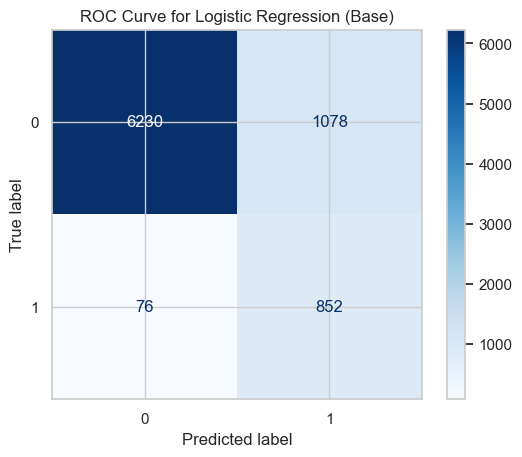

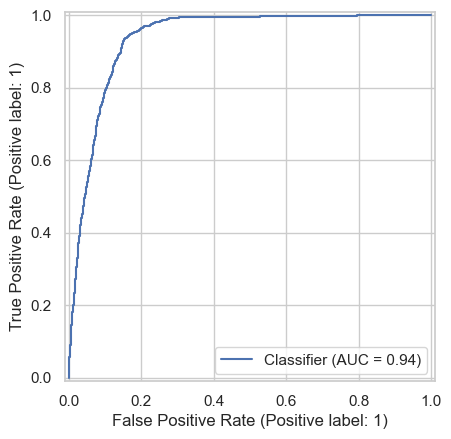

In [59]:
# Evaluating the Logistic Regression Base
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_resampled, y_train_resampled)

lr_base_metrics = evaluate_model(
    lr_base, 
    X_test, 
    y_test, 
    model_name="Logistic Regression (Base)"
)


-------------------- Decision Tree (Base) Evaluation --------------------
Accuracy:           0.8806
Sensitivity/Recall: 0.5442
Specificity:        0.9234
F1-Score:           0.5068
AUC-ROC:            0.7338


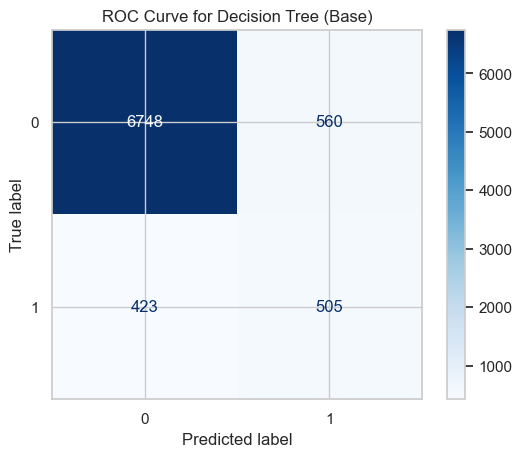

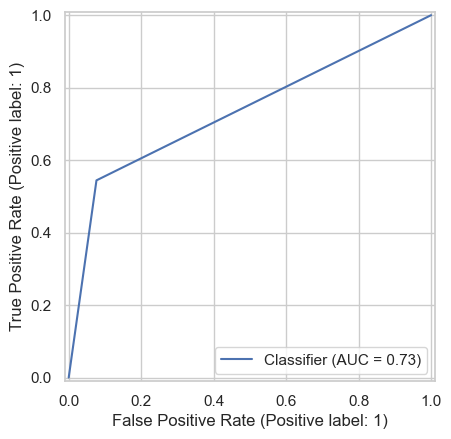

In [60]:
# Evaluating the Decision Tree Base
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_resampled, y_train_resampled)

dt_base_metrics = evaluate_model(
    dt_base, 
    X_test, 
    y_test, 
    model_name="Decision Tree (Base)"
)


-------------------- Random Forest (Base) Evaluation --------------------
Accuracy:           0.9072
Sensitivity/Recall: 0.5884
Specificity:        0.9477
F1-Score:           0.5884
AUC-ROC:            0.9423


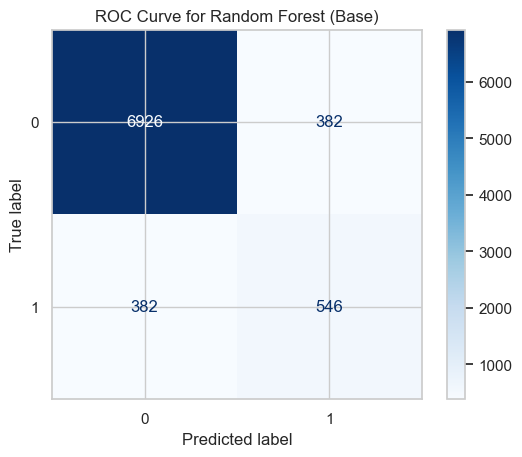

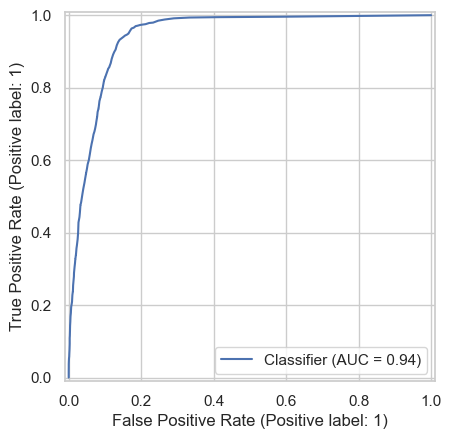

In [61]:
# Evaluating the Random Forest Base
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_resampled, y_train_resampled)

rf_base_metrics = evaluate_model(
    rf_base, 
    X_test, 
    y_test, 
    model_name="Random Forest (Base)"
)


-------------------- Gradient Boosting (Base) Evaluation --------------------
Accuracy:           0.8905
Sensitivity/Recall: 0.8287
Specificity:        0.8983
F1-Score:           0.6303
AUC-ROC:            0.9419


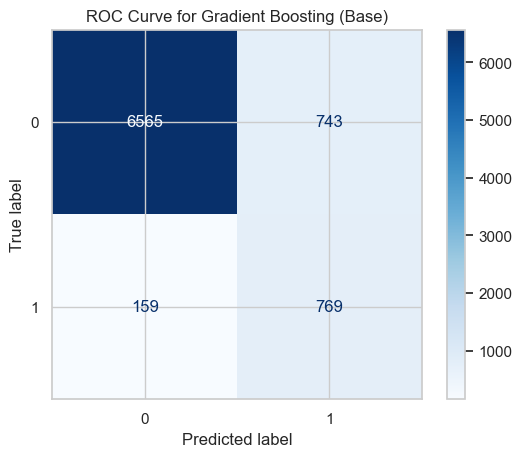

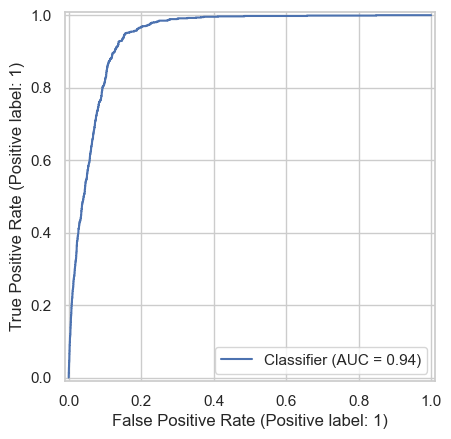

In [62]:
# Evaluating the Gradient Boosting Base
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train_resampled, y_train_resampled)

gb_base_metrics = evaluate_model(
    gb_base, 
    X_test, 
    y_test, 
    model_name="Gradient Boosting (Base)"
)

In [63]:
# Generate the comparison table for base classifiers
all_base_metrics = [lr_base_metrics, dt_base_metrics, rf_base_metrics, gb_base_metrics]
base_model_comparison = compare_models(all_base_metrics)
display(base_model_comparison)

,Model,Accuracy,Sensitivity,Specificity,F1-Score,AUC-ROC
0,Logistic Regression (Base),85.99%,91.81%,85.25%,59.62%,93.61%
1,Decision Tree (Base),88.06%,54.42%,92.34%,50.68%,73.38%
2,Random Forest (Base),90.72%,58.84%,94.77%,58.84%,94.23%
3,Gradient Boosting (Base),89.05%,82.87%,89.83%,63.03%,94.19%


### **Evaluating Models Tuned using RandomizedSearchCV**


-------------------- Logistic Regression (Tuned with RandomizedSearchCV) Evaluation --------------------
Accuracy:           0.8595
Sensitivity/Recall: 0.9149
Specificity:        0.8525
F1-Score:           0.5947
AUC-ROC:            0.9360


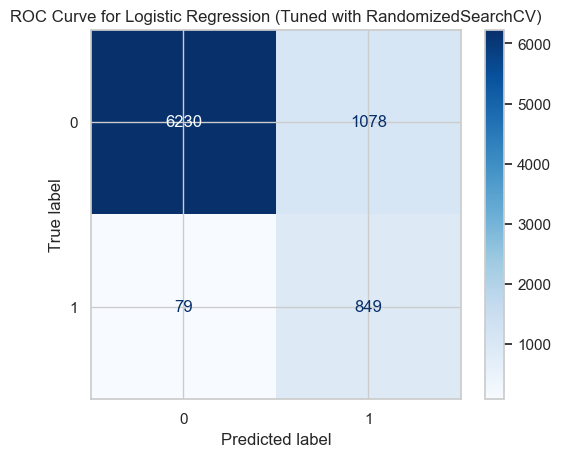

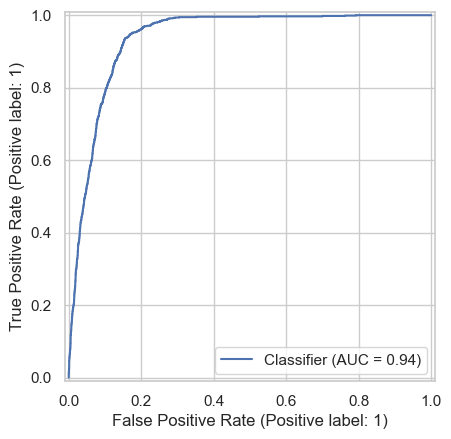

In [64]:
# Evaluating the Logistic Regression Tuned with RandomizedSearchCV
random_tuned_lr = lr_random_result.best_estimator_

random_tuned_lr_metrics = evaluate_model(
    random_tuned_lr,
    X_test,
    y_test,
    model_name="Logistic Regression (Tuned with RandomizedSearchCV)"
)


-------------------- Decision Tree (Tuned with RandomizedSearchCV) Evaluation --------------------
Accuracy:           0.8814
Sensitivity/Recall: 0.5183
Specificity:        0.9275
F1-Score:           0.4961
AUC-ROC:            0.7664


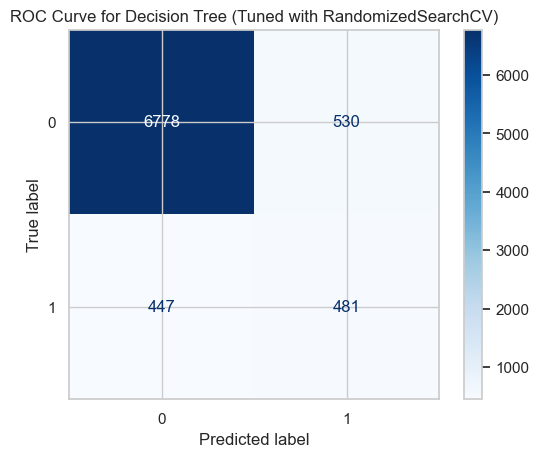

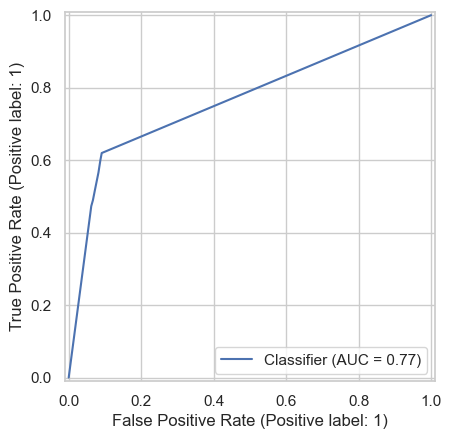

In [65]:
# Evaluating the Decision Tree Tuned with RandomizedSearchCV
random_tuned_dt = dt_random_result.best_estimator_

random_tuned_dt_metrics = evaluate_model(
    random_tuned_dt,
    X_test,
    y_test,
    model_name="Decision Tree (Tuned with RandomizedSearchCV)"
)


-------------------- Random Forest (Tuned with RandomizedSearchCV) Evaluation --------------------
Accuracy:           0.9066
Sensitivity/Recall: 0.5873
Specificity:        0.9472
F1-Score:           0.5863
AUC-ROC:            0.9430


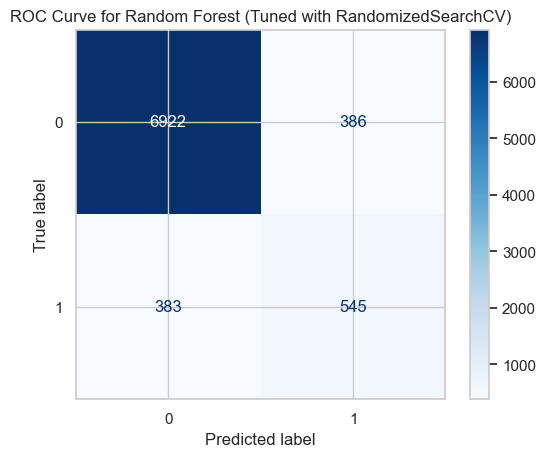

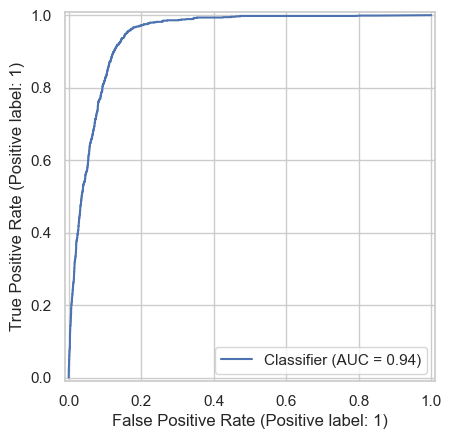

In [66]:
# Evaluating the Random Forest Tuned with RandomizedSearchCV
random_tuned_rf = rf_random_result.best_estimator_

random_tuned_rf_metrics = evaluate_model(
    random_tuned_rf,
    X_test,
    y_test,
    model_name="Random Forest (Tuned with RandomizedSearchCV)"
)


-------------------- Gradient Boosting (Tuned with RandomizedSearchCV) Evaluation --------------------
Accuracy:           0.8974
Sensitivity/Recall: 0.7985
Specificity:        0.9100
F1-Score:           0.6369
AUC-ROC:            0.9428


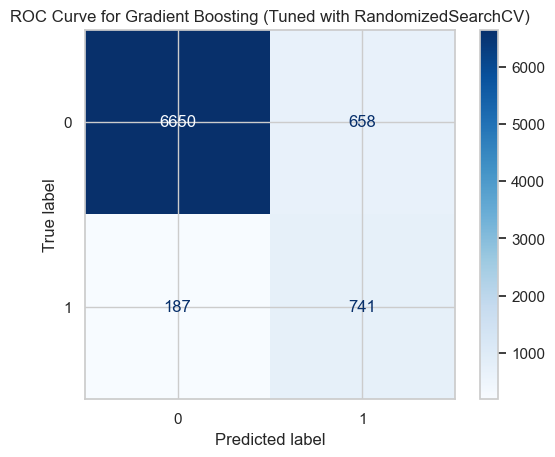

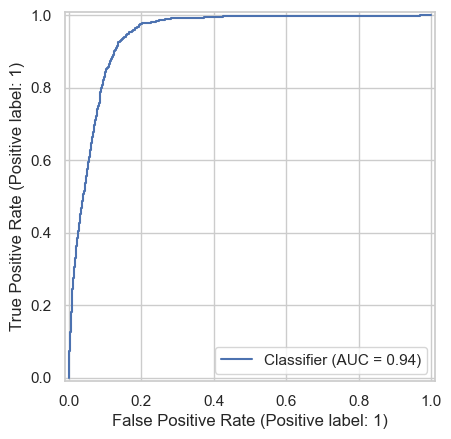

In [67]:
# Evaluating the Gradient Boosting Tuned with RandomizedSearchCV
random_tuned_gb = gb_random_result.best_estimator_

random_tuned_gb_metrics = evaluate_model(
    random_tuned_gb,
    X_test,
    y_test,
    model_name="Gradient Boosting (Tuned with RandomizedSearchCV)"
)

In [68]:
# Generate the comparison table for classfiers tuned with RandomizedSearchCV
all_random_tuned_metrics = [random_tuned_lr_metrics, random_tuned_dt_metrics, random_tuned_rf_metrics, random_tuned_gb_metrics]
random_tuned_model_comparison = compare_models(all_random_tuned_metrics)
display(random_tuned_model_comparison)

,Model,Accuracy,Sensitivity,Specificity,F1-Score,AUC-ROC
0,Logistic Regression (Tuned with RandomizedSearchCV),85.95%,91.49%,85.25%,59.47%,93.60%
1,Decision Tree (Tuned with RandomizedSearchCV),88.14%,51.83%,92.75%,49.61%,76.64%
2,Random Forest (Tuned with RandomizedSearchCV),90.66%,58.73%,94.72%,58.63%,94.30%
3,Gradient Boosting (Tuned with RandomizedSearchCV),89.74%,79.85%,91.00%,63.69%,94.28%


### **Evaluating Models Tuned using GridSearchCV**


-------------------- Gradient Boosting (Tuned with GridSearchCV) Evaluation --------------------
Accuracy:           0.8595
Sensitivity/Recall: 0.9149
Specificity:        0.8525
F1-Score:           0.5947
AUC-ROC:            0.9360


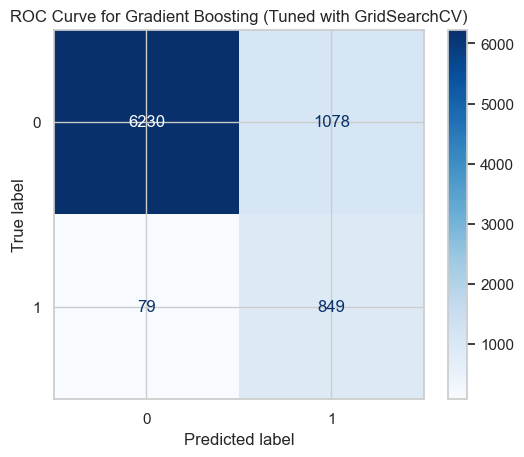

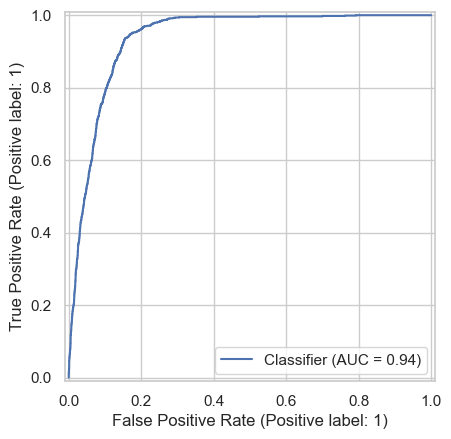

In [69]:
# Evaluating the Logistic Regression Tuned with GridSearchCV
grid_tuned_lr = lr_grid_result.best_estimator_

grid_tuned_lr_metrics = evaluate_model(
    grid_tuned_lr,
    X_test,
    y_test,
    model_name="Gradient Boosting (Tuned with GridSearchCV)"
)


-------------------- Decision Tree (Tuned with GridSearchCV) Evaluation --------------------
Accuracy:           0.8840
Sensitivity/Recall: 0.6013
Specificity:        0.9200
F1-Score:           0.5389
AUC-ROC:            0.7704


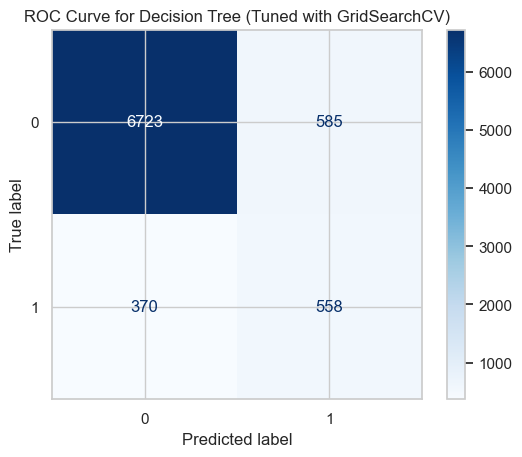

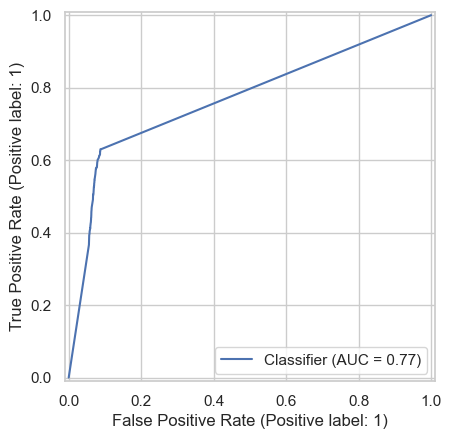

In [70]:
# Evaluating the Decision Tree Tuned with GridSearchCV
grid_tuned_dt = dt_grid_result.best_estimator_

grid_tuned_dt_metrics = evaluate_model(
    grid_tuned_dt,
    X_test,
    y_test,
    model_name="Decision Tree (Tuned with GridSearchCV)"
)


-------------------- Random Forest (Tuned with GridSearchCV) Evaluation --------------------
Accuracy:           0.9100
Sensitivity/Recall: 0.5237
Specificity:        0.9591
F1-Score:           0.5674
AUC-ROC:            0.9385


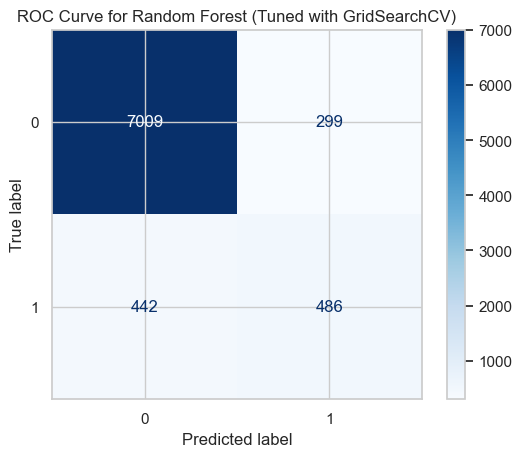

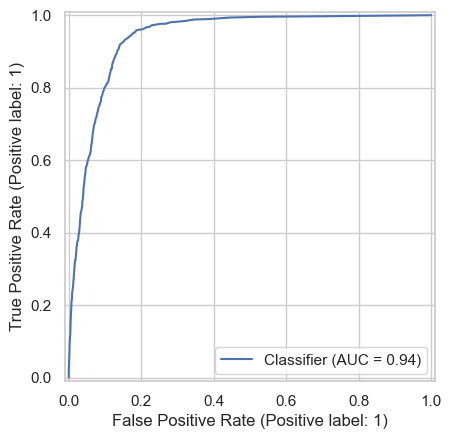

In [71]:
# Evaluating the Random Forest with GridSearchCV
grid_tuned_rf = rf_grid_result.best_estimator_

grid_tuned_rf_metrics = evaluate_model(
    grid_tuned_rf,
    X_test,
    y_test,
    model_name="Random Forest (Tuned with GridSearchCV)"
)


-------------------- Gradient Boosting (Tuned with GridSearchCV) Evaluation --------------------
Accuracy:           0.8972
Sensitivity/Recall: 0.7963
Specificity:        0.9100
F1-Score:           0.6357
AUC-ROC:            0.9431


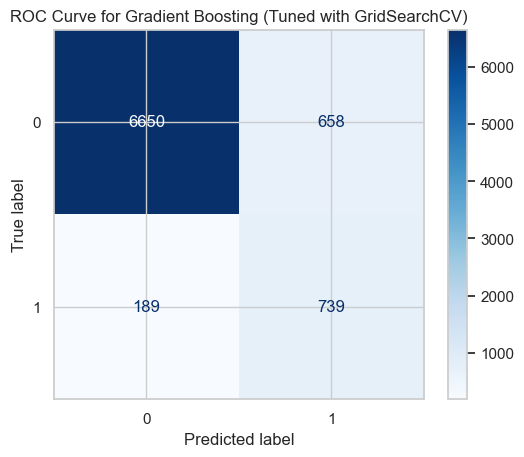

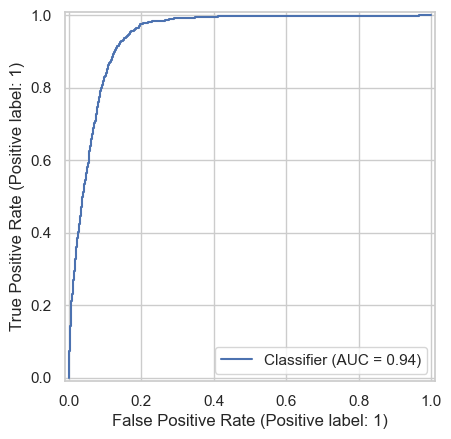

In [72]:
# Evaluating the Gradient Boosting with GridSearchCV
grid_tuned_gb = gb_grid_result.best_estimator_

grid_tuned_gb_metrics = evaluate_model(
    grid_tuned_gb,
    X_test,
    y_test,
    model_name="Gradient Boosting (Tuned with GridSearchCV)"
)

In [73]:
# Generate the comparison table for classfiers tuned with GridSearchCV
all_grid_tuned_metrics = [grid_tuned_lr_metrics, grid_tuned_dt_metrics, grid_tuned_rf_metrics, grid_tuned_gb_metrics]
grid_tuned_model_comparison = compare_models(all_grid_tuned_metrics)
display(grid_tuned_model_comparison)

,Model,Accuracy,Sensitivity,Specificity,F1-Score,AUC-ROC
0,Gradient Boosting (Tuned with GridSearchCV),85.95%,91.49%,85.25%,59.47%,93.60%
1,Decision Tree (Tuned with GridSearchCV),88.40%,60.13%,92.00%,53.89%,77.04%
2,Random Forest (Tuned with GridSearchCV),91.00%,52.37%,95.91%,56.74%,93.85%
3,Gradient Boosting (Tuned with GridSearchCV),89.72%,79.63%,91.00%,63.57%,94.31%


---

## **Clustering**

Clustering is one of the data mining techniques that can find subgroups, or clusters. in a dataset.

For Clustering Part, the K-Means Clustering will be used.

### **K-Means Clustering**

K-means clustering is one of the ways to cluster by partition a dataset into K distinct, non-overlapping clusters.The number of clusters K need to be specify to perform K-means clustering.

The Algorithm of K-Means Clustering will be described as followed:

1. Select K points as initial centriods
2. The K clusters assigning each point to its closest centroid and recompute the mean point of each cluster.
3. Repeat Step 2 until the convergence criterion is satisfied

To determine which number of clustering is the most suitable for K-Means Clustering, The Elbow method will be used to determine the most suitable numbers for K-Means Clustering.

In [74]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

'''
ColumnTransformer is a class in the scikit-learn Python machine learning library that
allows to selectively apply data preparation transforms to different columns in a dataset.
'''
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
'''
Principal component analysis (PCA) is a dimensionality reduction and
machine learning method used to simplify a large data set into a smaller set while
still maintaining significant patterns and trends
'''
from sklearn.decomposition import PCA

In [75]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
subscribed        0
dtype: int64

In [76]:
# Drop target variable and duration column for clustering
clustering_data = df.drop(columns=['subscribed', 'duration'])

# Copy the original dataframe
df2  = df.copy(deep = True)
# Convert target variable to binary (1 for "yes", 0 for "no")
df2['subscribed'] = df2['subscribed'].apply(lambda x: 1 if x == 'yes' else 0)

# Replace "unknown" with NaN for better handling
clustering_data.replace('unknown', np.nan, inplace=True)
df2.replace('unknown', np.nan, inplace=True)

In [77]:
clustering_data.isnull().sum()

age                  0
job                330
marital             80
education         1730
default           8596
housing            990
loan               990
contact              0
month                0
day_of_week          0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
dtype: int64

In [78]:
df2.isnull().sum()

age                  0
job                330
marital             80
education         1730
default           8596
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
subscribed           0
dtype: int64

In [79]:
# Dropping the null values
clustering_data.dropna(inplace = True)
df2.dropna(inplace = True)

In [80]:
clustering_data.shape

(30478, 19)

In [81]:
df2.shape

(30478, 21)

In [82]:
clustering_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30478 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30478 non-null  float64
 1   job             30478 non-null  object 
 2   marital         30478 non-null  object 
 3   education       30478 non-null  object 
 4   default         30478 non-null  object 
 5   housing         30478 non-null  object 
 6   loan            30478 non-null  object 
 7   contact         30478 non-null  object 
 8   month           30478 non-null  object 
 9   day_of_week     30478 non-null  object 
 10  campaign        30478 non-null  float64
 11  pdays           30478 non-null  float64
 12  previous        30478 non-null  float64
 13  poutcome        30478 non-null  object 
 14  emp.var.rate    30478 non-null  float64
 15  cons.price.idx  30478 non-null  float64
 16  cons.conf.idx   30478 non-null  float64
 17  euribor3m       30478 non-null  floa

In [83]:
# Separate categorical and numeric columns
categorical_cols = clustering_data.select_dtypes(include=['object']).columns
numerical_cols = clustering_data.select_dtypes(include=['float64', 'int64']).columns

# Preprocessing: Scaling and Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Scale numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # One-hot encode categorical features
    ]
)

# Apply transformations
processed_data = preprocessor.fit_transform(clustering_data)

In [84]:
processed_data

array([[ 1.70167518, -0.8139319 ,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [-0.19382419, -0.8139319 ,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.10546518, -0.8139319 ,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.70167518, -0.16053106,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.50451768, -0.8139319 ,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 3.04847736,  0.49286979,  0.        , ...,  1.        ,
         0.        ,  0.        ]])

In [85]:
# Determine Optimal Clusters
"""
Inertia, in simpler terms, it's the sum of the distances of each data point in
a cluster to the centroid of that cluster, squared and summed up for all clusters.
"""
ssd = []
K = range(2, 11)  # Test cluster sizes from 2 to 10
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(processed_data)
    ssd.append(kmeans.inertia_)

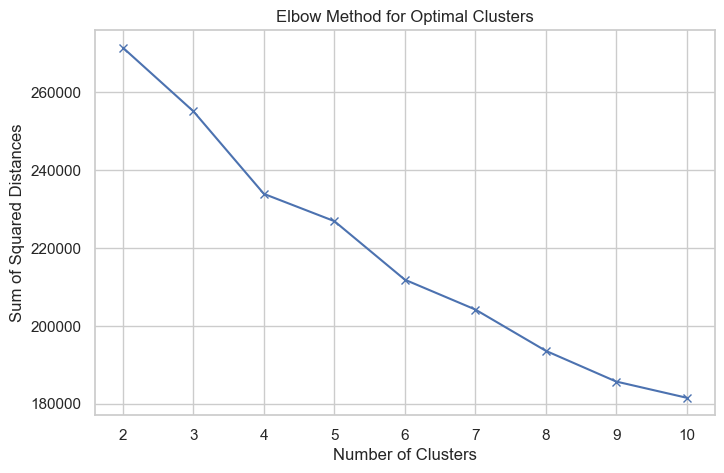

In [86]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, ssd, 'bx-')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

In this case, we can see that the optimal number of clusters are 4 based on the elbow method.

In [87]:
# Fit K-Means with Optimal Clusters
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(processed_data)

# Add cluster labels to the dataset
df2['Cluster'] = cluster_labels

In [88]:
# Evaluate Clustering with Silhouette Score
sil_score = silhouette_score(processed_data, cluster_labels)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.1710


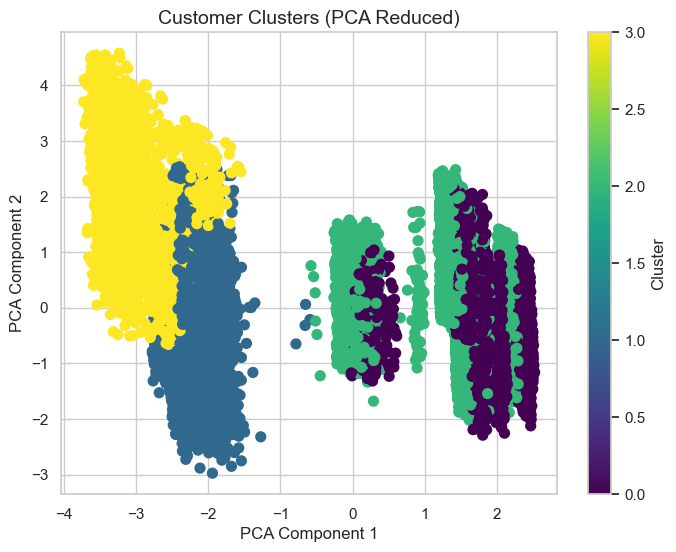

In [89]:
# Visualize Clusters with PCA
pca = PCA(n_components=2, random_state=42)
reduced_data = pca.fit_transform(processed_data)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title('Customer Clusters (PCA Reduced)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

<p align='justify'>
The plot shows four distinct clusters (0, 1, 2, 3) with different colors, as indicated by the legend. Each cluster represents a group of points that the algorithm identified as similar based on the dataset's features.
<br><br>
Some clusters, like the yellow and blue groups, seem well-separated in the PCA-reduced space, indicating distinct groupings. However, there is some overlap between clusters (e.g., green and purple groups). This might indicate less-defined boundaries in the original high-dimensional feature space.

In [90]:
# Analyze Clusters
# Cluster-wise subscription rates
cluster_analysis = df2.groupby(df2['Cluster'])[['age', 'campaign', 'pdays', 'previous', 'subscribed']].mean()
display(cluster_analysis)

,age,campaign,pdays,previous,subscribed
Cluster,,,,,
0,39.150366,5.136720,999.0,0.0,0.048269
1,37.612127,2.073464,999.0,0.0,0.210969
2,38.811333,1.669800,999.0,0.0,0.051182
3,44.332220,1.785893,999.0,0.0,0.427796


In [91]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30478 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30478 non-null  float64
 1   job             30478 non-null  object 
 2   marital         30478 non-null  object 
 3   education       30478 non-null  object 
 4   default         30478 non-null  object 
 5   housing         30478 non-null  object 
 6   loan            30478 non-null  object 
 7   contact         30478 non-null  object 
 8   month           30478 non-null  object 
 9   day_of_week     30478 non-null  object 
 10  duration        30478 non-null  float64
 11  campaign        30478 non-null  float64
 12  pdays           30478 non-null  float64
 13  previous        30478 non-null  float64
 14  poutcome        30478 non-null  object 
 15  emp.var.rate    30478 non-null  float64
 16  cons.price.idx  30478 non-null  float64
 17  cons.conf.idx   30478 non-null  floa

In [92]:
categorical_cols = df2.select_dtypes(include=['object']).columns

# Perform one-hot encoding
df2_encoded = pd.get_dummies(df2, columns=categorical_cols)

In [93]:
df2_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30478 entries, 0 to 41187
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            30478 non-null  float64
 1   duration                       30478 non-null  float64
 2   campaign                       30478 non-null  float64
 3   pdays                          30478 non-null  float64
 4   previous                       30478 non-null  float64
 5   emp.var.rate                   30478 non-null  float64
 6   cons.price.idx                 30478 non-null  float64
 7   cons.conf.idx                  30478 non-null  float64
 8   euribor3m                      30478 non-null  float64
 9   nr.employed                    30478 non-null  float64
 10  subscribed                     30478 non-null  int64  
 11  Cluster                        30478 non-null  int32  
 12  job_admin.                     30478 non-null  bool

In [94]:
# Perform cluster analysis for job types and marital status
cluster_analysis_2 = df2_encoded.groupby(df2_encoded['Cluster'])[[col for col in df2_encoded.columns if col.startswith("job_")] + ["subscribed", "marital_divorced", "marital_single", "marital_married"]].mean()
print("Job Types and Marital Status:")
display(cluster_analysis_2)

# Sort values by subscribed
cluster_target_analysis = cluster_analysis_2.sort_values(by="subscribed", ascending=False)
print()
print("Sorted by Subscribed:")
display(cluster_target_analysis)

Job Types and Marital Status:


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,subscribed,marital_divorced,marital_single,marital_married
Cluster,,,,,,,,,,,,,,,
0,0.305534,0.176902,0.033106,0.025524,0.076068,0.026283,0.040182,0.091736,0.005812,0.196361,0.022492,0.048269,0.132171,0.280768,0.587061
1,0.281594,0.211990,0.031225,0.012717,0.068241,0.039514,0.033950,0.105257,0.038833,0.153174,0.023504,0.210969,0.100942,0.378449,0.520609
2,0.278365,0.193955,0.041781,0.026048,0.080624,0.021543,0.036101,0.096553,0.006137,0.196893,0.022000,0.051182,0.122927,0.276015,0.601058
3,0.325960,0.056761,0.017947,0.032554,0.072621,0.180718,0.033806,0.036311,0.063022,0.136477,0.043823,0.427796,0.107262,0.320117,0.572621



Sorted by Subscribed:


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,subscribed,marital_divorced,marital_single,marital_married
Cluster,,,,,,,,,,,,,,,
3,0.325960,0.056761,0.017947,0.032554,0.072621,0.180718,0.033806,0.036311,0.063022,0.136477,0.043823,0.427796,0.107262,0.320117,0.572621
1,0.281594,0.211990,0.031225,0.012717,0.068241,0.039514,0.033950,0.105257,0.038833,0.153174,0.023504,0.210969,0.100942,0.378449,0.520609
2,0.278365,0.193955,0.041781,0.026048,0.080624,0.021543,0.036101,0.096553,0.006137,0.196893,0.022000,0.051182,0.122927,0.276015,0.601058
0,0.305534,0.176902,0.033106,0.025524,0.076068,0.026283,0.040182,0.091736,0.005812,0.196361,0.022492,0.048269,0.132171,0.280768,0.587061


<strong>Interpretation:</strong>

For Job Status:

<strong>Cluster 3:</strong> Retired Individuals, administrative jobs and unemployed individuals having high subscription on it
<br><br>
<strong>Cluster 1:</strong> Blue-Collar Jobs, Services Jobs, and Student having a moderate subscription on it.

<strong>Interpretation:</strong>

For Marital Status:

<strong>Cluster 3:</strong> For Married Individuals might influence the likelihood of the subscription.
<br><br>
<strong>Cluster 1:</strong> Single Individuals having moderate subscription on it.

In [95]:
# Perform cluster analysis for education and default status
cluster_analysis_2 = df2_encoded.groupby(df2_encoded['Cluster'])[[col for col in df2_encoded.columns if col.startswith("education_")] + ["subscribed", "default_no", "default_yes"]].mean()
print("Education and Default Status:")
display(cluster_analysis_2)

# Sort values by subscribed
cluster_target_analysis = cluster_analysis_2.sort_values(by="subscribed", ascending=False)
print()
print("Sorted by Subscribed:")
display(cluster_target_analysis)

Education and Default Status:


,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,subscribed,default_no,default_yes
Cluster,,,,,,,,,,
0,0.068739,0.041446,0.132171,0.244377,0.000000,0.151377,0.361890,0.048269,1.000000,0.000000
1,0.076189,0.048598,0.154763,0.270126,0.000227,0.127966,0.322130,0.210969,1.000000,0.000000
2,0.075075,0.048440,0.145972,0.248531,0.000457,0.147931,0.333594,0.051182,0.999804,0.000196
3,0.119783,0.022538,0.064274,0.227045,0.000835,0.136060,0.429466,0.427796,1.000000,0.000000



Sorted by Subscribed:


,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,subscribed,default_no,default_yes
Cluster,,,,,,,,,,
3,0.119783,0.022538,0.064274,0.227045,0.000835,0.136060,0.429466,0.427796,1.000000,0.000000
1,0.076189,0.048598,0.154763,0.270126,0.000227,0.127966,0.322130,0.210969,1.000000,0.000000
2,0.075075,0.048440,0.145972,0.248531,0.000457,0.147931,0.333594,0.051182,0.999804,0.000196
0,0.068739,0.041446,0.132171,0.244377,0.000000,0.151377,0.361890,0.048269,1.000000,0.000000


<strong>Interpretation:</strong>

For Education Status:

<strong>Cluster 3:</strong> For the university degrees having the most individuals for subscription, then followed by high school education and professional courses.
<br><br>
<strong>Cluster 1:</strong> For the moderate subscription, basic education, high school graduates and university degrees individual are involved in it.

<strong>Interpretation:</strong>

For Default Status:

<strong>default_no:</strong> For the individual has no history on loan, there is having 100% or close to 100% in all clusters.
<br><br>
<strong>default_yes:</strong> For the individual  having history on loan, almost all clusters is near 0% which shows that having defaulting is not significant factore to determine the likelihood of subscription.

In [96]:
# Perform cluster analysis for housing, loan, and contact status
cluster_analysis_2 = df2_encoded.groupby(df2_encoded['Cluster'])[[col for col in df2_encoded.columns if col.startswith("housing_")] + ["subscribed", "loan_no", "loan_yes","contact_cellular","contact_telephone"]].mean()
print("Housing, Loan, and Contact Status:")
display(cluster_analysis_2)

# Sort values by subscribed
cluster_target_analysis = cluster_analysis_2.sort_values(by="subscribed", ascending=False)
print()
print("Sorted by Subscribed:")
display(cluster_target_analysis)

Housing, Loan, and Contact Status:


,housing_no,housing_yes,subscribed,loan_no,loan_yes,contact_cellular,contact_telephone
Cluster,,,,,,,
0,0.491281,0.508719,0.048269,0.843821,0.156179,0.531211,0.468789
1,0.414897,0.585103,0.210969,0.836153,0.163847,0.903713,0.096287
2,0.476107,0.523893,0.051182,0.844888,0.155112,0.539953,0.460047
3,0.446995,0.553005,0.427796,0.861853,0.138147,0.877713,0.122287



Sorted by Subscribed:


,housing_no,housing_yes,subscribed,loan_no,loan_yes,contact_cellular,contact_telephone
Cluster,,,,,,,
3,0.446995,0.553005,0.427796,0.861853,0.138147,0.877713,0.122287
1,0.414897,0.585103,0.210969,0.836153,0.163847,0.903713,0.096287
2,0.476107,0.523893,0.051182,0.844888,0.155112,0.539953,0.460047
0,0.491281,0.508719,0.048269,0.843821,0.156179,0.531211,0.468789


<strong>Interpretation:</strong>

For Housing Status:

<strong>Cluster 3:</strong> There having more individuals with housing loans have high subscription compared to individual without housing loan.
<br><br>
<strong>Cluster 1:</strong> For the moderate subscription, individuals with housing loans also higher than individuals without housing loan.

<strong>Interpretation:</strong>

For Loan Status:

<strong>loan_no:</strong> the majority of inidividuals does not having loans in high subscription in all clusters.
<br><br>
<strong>loan_yes:</strong> There is a small proportion of indivduals having loans in all clusters.

<strong>Interpretation:</strong>

For Contact Type:

<strong>Cluster 3:</strong> The majority of contacts of high subscription were made using cellular instead of telephone.
<br><br>
<strong>Cluster 1:</strong> The contact of moderate subscription also using mostly cellular instead via telephone.

In [97]:
# Perform cluster analysis for poutcome status
cluster_analysis_2 = df2_encoded.groupby(df2_encoded['Cluster'])[[col for col in df2_encoded.columns if col.startswith("poutcome_")] + ["subscribed"]].mean()
print("Poutcome Status:")
display(cluster_analysis_2)

# Sort values by subscribed
cluster_target_analysis = cluster_analysis_2.sort_values(by="subscribed", ascending=False)
print()
print("Sorted by Subscribed:")
display(cluster_target_analysis)

Poutcome Status:


,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed
Cluster,,,,
0,0.014658,0.984584,0.000758,0.048269
1,0.259339,0.663790,0.076871,0.210969
2,0.034796,0.963507,0.001697,0.051182
3,0.244574,0.553005,0.202421,0.427796



Sorted by Subscribed:


,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed
Cluster,,,,
3,0.244574,0.553005,0.202421,0.427796
1,0.259339,0.663790,0.076871,0.210969
2,0.034796,0.963507,0.001697,0.051182
0,0.014658,0.984584,0.000758,0.048269


<strong>Interpretation:</strong>

<strong>poutcome_failure:</strong> There is having individuals with prior failures on higher subscription.  
<br><br>
<strong>poutcome_success:</strong> For the individuals with prior successes, there is highest proportion of individuals in highest subscription rate.

### **Resources**

<p align='justify'>

1.   https://www.analyticsvidhya.com/blog/2021/05/k-mean-getting-the-optimal-number-of-clusters/
2.   https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
3. https://www.geeksforgeeks.org/silhouette-algorithm-to-determine-the-optimal-value-of-k/?ref=rp